# Notebook 04 — Modelagem, Política de Crédito e Scoring

Este notebook integra o target selecionado às features point-in-time, compara modelos, valida a solução temporalmente, calibra as probabilidades, propõe uma política de crédito e gera o arquivo de submissão.

**Roteiro**

1. integrar target e features e definir treino, teste e out-of-time;
2. selecionar variáveis e comparar modelos com validação agrupada por cliente;
3. validar temporalmente, calibrar probabilidades e propor a política;
4. aplicar o pipeline à base de scoring, validar estabilidade e concluir a solução.


## 1. Configuração e preparação das fontes

O notebook consome as saídas reproduzíveis dos Notebooks 02 e 03: target final, features de desenvolvimento e features de scoring. Os dados permanecem em Spark até a definição das populações; a conversão para pandas ocorre uma única vez, antes da modelagem.

In [1]:
from pathlib import Path
import os
import sys
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import sklearn

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=FutureWarning)
SEMENTE = 42

# Garante que driver e workers do Spark utilizem o Python do kernel ativo.
PYTHON_EXECUTAVEL = str(Path(sys.executable).resolve())

os.environ["PYSPARK_PYTHON"] = PYTHON_EXECUTAVEL
os.environ["PYSPARK_DRIVER_PYTHON"] = PYTHON_EXECUTAVEL
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

try:
    spark.stop()
except (NameError, AttributeError):
    pass

spark = (
    SparkSession.builder
    .master(os.getenv("SPARK_MASTER", "local[2]"))
    .appName("credit-risk-case")
    .config("spark.ui.enabled", "false")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.pyspark.python", PYTHON_EXECUTAVEL)
    .config("spark.pyspark.driver.python", PYTHON_EXECUTAVEL)
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

CAMINHO_SAIDA_MANUAL = None


def resolver_caminho(caminho_manual, variavel_ambiente, caminho_databricks, caminho_local):
    if caminho_manual:
        return str(caminho_manual)
    if os.getenv(variavel_ambiente):
        return os.environ[variavel_ambiente]
    if caminho_databricks and Path(caminho_databricks).exists():
        return caminho_databricks
    return caminho_local


def juntar_caminho(diretorio, arquivo):
    return f"{str(diretorio).rstrip('/')}/{arquivo}"


OUTPUT_PATH = resolver_caminho(
    CAMINHO_SAIDA_MANUAL,
    "CREDIT_RISK_OUTPUT_PATH",
    "/Volumes/workspace/default/case_tecnico_ds",
    "outputs"
)

if "://" not in OUTPUT_PATH:
    Path(OUTPUT_PATH).mkdir(parents=True, exist_ok=True)


def visualizar(df, n=20, truncate=False):
    if n <= 0:
        raise ValueError("O parâmetro 'n' deve ser maior que zero.")

    if hasattr(df, "show") and hasattr(df, "limit"):
        df.show(n=n, truncate=truncate)
        return

    tabela = (
        df.head(n).copy()
        if isinstance(df, pd.DataFrame)
        else pd.DataFrame(df).head(n)
    )

    print(tabela.to_string(index=False))


print(
    f"Python: {sys.version.split()[0]} | Spark: {spark.version} | "
    f"pandas: {pd.__version__} | scikit-learn: {sklearn.__version__}"
)
print(f"Saídas: {OUTPUT_PATH}")

Python: 3.11.7 | Spark: 4.1.2 | pandas: 2.2.3 | scikit-learn: 1.8.0
Saídas: outputs


### 1.1 Leitura das saídas intermediárias

In [2]:
CAMINHO_BASE_DESENVOLVIMENTO = juntar_caminho(
    OUTPUT_PATH,
    "base_desenvolvimento_features.parquet"
)

CAMINHO_BASE_SCORING = juntar_caminho(
    OUTPUT_PATH,
    "base_scoring_features.parquet"
)

CAMINHO_TARGET_FINAL = juntar_caminho(
    OUTPUT_PATH,
    "base_target_final.parquet"
)

base_desenvolvimento_features = spark.read.parquet(
    CAMINHO_BASE_DESENVOLVIMENTO
)
base_scoring_features = spark.read.parquet(
    CAMINHO_BASE_SCORING
)
base_target_final = spark.read.parquet(
    CAMINHO_TARGET_FINAL
)

resumo_fontes = (
    base_desenvolvimento_features
    .agg(
        F.lit("FEATURES_DESENVOLVIMENTO").alias("fonte"),
        F.count("*").alias("qtd_registros"),
        F.countDistinct("id_avaliacao").alias("qtd_chaves_distintas"),
        F.lit(len(base_desenvolvimento_features.columns)).alias("qtd_colunas")
    )
    .unionByName(
        base_scoring_features.agg(
            F.lit("FEATURES_SCORING").alias("fonte"),
            F.count("*").alias("qtd_registros"),
            F.countDistinct("id_avaliacao").alias("qtd_chaves_distintas"),
            F.lit(len(base_scoring_features.columns)).alias("qtd_colunas")
        )
    )
    .unionByName(
        base_target_final.agg(
            F.lit("TARGET_FINAL").alias("fonte"),
            F.count("*").alias("qtd_registros"),
            F.countDistinct(F.struct("id_contrato", "id_cliente"))
                .alias("qtd_chaves_distintas"),
            F.lit(len(base_target_final.columns)).alias("qtd_colunas")
        )
    )
)

visualizar(resumo_fontes)

+------------------------+-------------+--------------------+-----------+
|fonte                   |qtd_registros|qtd_chaves_distintas|qtd_colunas|
+------------------------+-------------+--------------------+-----------+
|FEATURES_DESENVOLVIMENTO|107419       |107419              |78         |
|FEATURES_SCORING        |40000        |40000               |78         |
|TARGET_FINAL            |107419       |107419              |9          |
+------------------------+-------------+--------------------+-----------+



## 2. Integração do target e contrato de modelagem

O target é integrado às features de desenvolvimento pelas chaves `id_contrato` e `id_cliente`. A junção é realizada por meio de um LEFT JOIN, preservando todos os contratos da base principal e permitindo identificar explicitamente os casos sem target, evitando que contratos sejam excluídos sem rastreabilidade.

A base de scoring permanece separada e sem target. Ela será utilizada somente após a seleção do modelo e a definição final do pipeline

Também é validado o contrato entre desenvolvimento e scoring: ambas as bases devem possuir as mesmas features, na mesma ordem e com tipos compatíveis.

In [3]:
base_target_modelagem = (
    base_target_final
    .select(
        "id_contrato",
        "id_cliente",
        F.col("target").cast("int").alias("target")
    )
)

base_desenvolvimento_modelagem = (
    base_desenvolvimento_features.alias("features")
    .join(
        base_target_modelagem.alias("target"),
        on=["id_contrato", "id_cliente"],
        how="left"
    )
)

validacao_base_modelagem = (
    base_desenvolvimento_modelagem
    .agg(
        F.count("*").alias("qtd_registros"),
        F.countDistinct("id_avaliacao").alias("qtd_avaliacoes_distintas"),
        F.countDistinct(F.struct("id_contrato", "id_cliente"))
            .alias("qtd_contratos_distintos"),
        F.sum(F.col("target").isNull().cast("int")).alias("qtd_targets_nulos"),
        F.sum((F.col("target") == 0).cast("int")).alias("qtd_bons"),
        F.sum((F.col("target") == 1).cast("int")).alias("qtd_maus"),
        F.round(F.avg("target") * 100, 4).alias("taxa_maus"),
        F.min("data_avaliacao").alias("menor_data_avaliacao"),
        F.max("data_avaliacao").alias("maior_data_avaliacao")
    )
)

visualizar(validacao_base_modelagem)

resultado_validacao = validacao_base_modelagem.first()

if resultado_validacao["qtd_targets_nulos"] > 0:
    raise ValueError(
        f"Foram encontrados {resultado_validacao['qtd_targets_nulos']} "
        "contratos sem target após a integração."
    )

if resultado_validacao["qtd_registros"] != resultado_validacao["qtd_avaliacoes_distintas"]:
    raise ValueError("A base de desenvolvimento não possui uma linha por avaliação.")

+-------------+------------------------+-----------------------+-----------------+--------+--------+---------+--------------------+--------------------+
|qtd_registros|qtd_avaliacoes_distintas|qtd_contratos_distintos|qtd_targets_nulos|qtd_bons|qtd_maus|taxa_maus|menor_data_avaliacao|maior_data_avaliacao|
+-------------+------------------------+-----------------------+-----------------+--------+--------+---------+--------------------+--------------------+
|107419       |107419                  |107419                 |0                |103349  |4070    |3.7889   |2017-02-04          |2025-02-14          |
+-------------+------------------------+-----------------------+-----------------+--------+--------+---------+--------------------+--------------------+



In [4]:
COLUNAS_RASTREABILIDADE = {
    "id_avaliacao", "tipo_base", "id_cliente", "id_contrato",
    "data_avaliacao", "data_corte_features", "target"
}

colunas_features_desenvolvimento = [
    coluna for coluna in base_desenvolvimento_modelagem.columns
    if coluna not in COLUNAS_RASTREABILIDADE
]

colunas_features_scoring = [
    coluna for coluna in base_scoring_features.columns
    if coluna not in COLUNAS_RASTREABILIDADE
]

features_ausentes_scoring = sorted(
    set(colunas_features_desenvolvimento) - set(colunas_features_scoring)
)
features_extras_scoring = sorted(
    set(colunas_features_scoring) - set(colunas_features_desenvolvimento)
)

tipos_desenvolvimento = dict(
    base_desenvolvimento_modelagem
    .select(*colunas_features_desenvolvimento)
    .dtypes
)

tipos_scoring = dict(
    base_scoring_features
    .select(*colunas_features_scoring)
    .dtypes
)

features_tipos_incompativeis = [
    coluna for coluna in colunas_features_desenvolvimento
    if coluna in tipos_scoring
    and tipos_desenvolvimento[coluna] != tipos_scoring[coluna]
]

print(f"Features de desenvolvimento: {len(colunas_features_desenvolvimento)}")
print(f"Features de scoring: {len(colunas_features_scoring)}")
print(f"Ausentes no scoring: {features_ausentes_scoring}")
print(f"Extras no scoring: {features_extras_scoring}")
print(f"Tipos incompatíveis: {features_tipos_incompativeis}")
print(
    "Mesma ordem:",
    colunas_features_desenvolvimento == colunas_features_scoring
)

if features_ausentes_scoring or features_extras_scoring or features_tipos_incompativeis:
    raise ValueError("Desenvolvimento e scoring possuem contratos de features incompatíveis.")

Features de desenvolvimento: 72
Features de scoring: 72
Ausentes no scoring: []
Extras no scoring: []
Tipos incompatíveis: []
Mesma ordem: True


**Decisão de integração**

A base de desenvolvimento permaneceu com uma linha por avaliação e cobertura integral do target. Desenvolvimento e scoring possuem o mesmo contrato de features, permitindo que o pipeline aprendido no treino seja aplicado sem reconstruções específicas para a população de submissão.

A base de scoring não participa da imputação, seleção de variáveis, definição de categorias, ajuste de hiperparâmetros ou escolha do modelo.

## 3. Definição das populações de desenvolvimento e avaliação

A população com target conhecido foi organizada em duas etapas.

Primeiro, o período mais recente foi reservado como **out-of-time**, permanecendo completamente fora das decisões de desenvolvimento. Essa população será utilizada para avaliar a capacidade de generalização temporal do modelo final.

Os registros anteriores ao out-of-time formam a população de **desenvolvimento**, posteriormente dividida em:

* **Treino — 70%:** utilizado para aprender tratamentos, imputações, codificações, selecionar variáveis e estimar os parâmetros dos modelos.
* **Teste — 30%:** utilizado para comparar os modelos candidatos e avaliar a performance fora da amostra de treino.

A validação necessária para ajuste de hiperparâmetros será executada internamente, exclusivamente dentro da amostra de treino, por meio dos mecanismos da biblioteca de modelagem.

A base de scoring constitui uma população adicional, sem target conhecido, e será utilizada somente após a escolha e a definição do pipeline final.

A estratégia separa quatro funções:

1. aprendizado do modelo no treino;
2. avaliação out-of-sample no teste;
3. avaliação temporal no out-of-time;
4. aplicação do modelo na base de scoring.

**Estratégia das populações**

| População         | Target |    Participa do desenvolvimento | Finalidade                           |
| ----------------- | -----: | ------------------------------: | ------------------------------------ |
| Treino            |    Sim |                             Sim | Aprender tratamentos e parâmetros    |
| Validação interna |    Sim |                Dentro do treino | Ajustar hiperparâmetros              |
| Teste             |    Sim | Apenas para avaliação e seleção | Avaliar performance out-of-sample    |
| Out-of-time       |    Sim |                             Não | Avaliar generalização temporal       |
| Scoring           |    Não |                             Não | Gerar as probabilidades da submissão |

O teste não será utilizado para aprender imputações ou parâmetros do modelo. O out-of-time não será utilizado para selecionar variáveis, modelos ou hiperparâmetros.

### 3.1 Distribuição temporal e definição do out-of-time

In [5]:
distribuicao_anual = (
    base_desenvolvimento_modelagem
    .withColumn("ano_avaliacao", F.year("data_avaliacao"))
    .groupBy("ano_avaliacao")
    .agg(
        F.count("*").alias("qtd_avaliacoes"),
        F.sum("target").alias("qtd_maus"),
        F.round(F.avg("target") * 100, 4).alias("taxa_maus")
    )
    .withColumn(
        "perc_base",
        F.round(
            F.col("qtd_avaliacoes")
            / F.sum("qtd_avaliacoes").over(Window.partitionBy()) * 100,
            4
        )
    )
    .orderBy("ano_avaliacao")
)

visualizar(distribuicao_anual, n=20)

+-------------+--------------+--------+---------+---------+
|ano_avaliacao|qtd_avaliacoes|qtd_maus|taxa_maus|perc_base|
+-------------+--------------+--------+---------+---------+
|2017         |6710          |380     |5.6632   |6.2466   |
|2018         |8925          |418     |4.6835   |8.3086   |
|2019         |7598          |379     |4.9882   |7.0732   |
|2020         |8913          |374     |4.1961   |8.2974   |
|2021         |10993         |425     |3.8661   |10.2338  |
|2022         |17924         |741     |4.1341   |16.6861  |
|2023         |25470         |854     |3.353    |23.7109  |
|2024         |20700         |496     |2.3961   |19.2703  |
|2025         |186           |3       |1.6129   |0.1732   |
+-------------+--------------+--------+---------+---------+



In [6]:
DATA_INICIO_OUT_OF_TIME = "2024-03-01"
data_avaliacao = F.col("data_avaliacao")

base_desenvolvimento_historico = base_desenvolvimento_modelagem.filter(
    data_avaliacao < F.lit(DATA_INICIO_OUT_OF_TIME)
)

base_out_of_time = base_desenvolvimento_modelagem.filter(
    data_avaliacao >= F.lit(DATA_INICIO_OUT_OF_TIME)
)

def resumir_populacao(df, nome):
    return df.agg(
        F.lit(nome).alias("populacao"),
        F.count("*").alias("qtd_avaliacoes"),
        F.countDistinct("id_cliente").alias("qtd_clientes"),
        F.sum("target").alias("qtd_maus"),
        (F.count("*") - F.sum("target")).alias("qtd_bons"),
        F.round(F.avg("target") * 100, 4).alias("taxa_maus"),
        F.min("data_avaliacao").alias("menor_data"),
        F.max("data_avaliacao").alias("maior_data")
    )

resumo_populacoes_temporais = (
    resumir_populacao(base_desenvolvimento_historico, "DESENVOLVIMENTO")
    .unionByName(resumir_populacao(base_out_of_time, "OUT_OF_TIME"))
    .withColumn(
        "perc_base",
        F.round(
            F.col("qtd_avaliacoes")
            / F.sum("qtd_avaliacoes").over(Window.partitionBy()) * 100,
            4
        )
    )
)

visualizar(resumo_populacoes_temporais)

+---------------+--------------+------------+--------+--------+---------+----------+----------+---------+
|populacao      |qtd_avaliacoes|qtd_clientes|qtd_maus|qtd_bons|taxa_maus|menor_data|maior_data|perc_base|
+---------------+--------------+------------+--------+--------+---------+----------+----------+---------+
|DESENVOLVIMENTO|90903         |35149       |3686    |87217   |4.0549   |2017-02-04|2024-02-29|84.6247  |
|OUT_OF_TIME    |16516         |13592       |384     |16132   |2.325    |2024-03-01|2025-02-14|15.3753  |
+---------------+--------------+------------+--------+--------+---------+----------+----------+---------+



**Validação da recorrência de clientes**

Antes da separação entre treino e teste, é necessário verificar se um mesmo cliente possui múltiplas avaliações na população de desenvolvimento.

Caso exista recorrência, os contratos de um cliente devem permanecer em uma única amostra. Essa restrição reduz o risco de o teste conter perfis muito semelhantes aos observados no treino.

In [7]:
validacao_recorrencia_clientes = (
    base_desenvolvimento_historico
    .agg(
        F.count("*").alias("qtd_avaliacoes"),
        F.countDistinct("id_cliente").alias("qtd_clientes"),
        F.countDistinct(F.struct("id_cliente", "id_contrato")).alias("qtd_contratos")
    )
    .withColumn(
        "qtd_avaliacoes_adicionais",
        F.col("qtd_avaliacoes") - F.col("qtd_clientes")
    )
    .withColumn(
        "perc_avaliacoes_adicionais",
        F.round(F.col("qtd_avaliacoes_adicionais") / F.col("qtd_avaliacoes") * 100, 4)
    )
)

visualizar(validacao_recorrencia_clientes)

+--------------+------------+-------------+-------------------------+--------------------------+
|qtd_avaliacoes|qtd_clientes|qtd_contratos|qtd_avaliacoes_adicionais|perc_avaliacoes_adicionais|
+--------------+------------+-------------+-------------------------+--------------------------+
|90903         |35149       |90903        |55754                    |61.3335                   |
+--------------+------------+-------------+-------------------------+--------------------------+



**Decisão sobre a definição do out-of-time**

O período iniciado em março de 2024 foi reservado como out-of-time, permanecendo completamente fora das decisões de desenvolvimento.

A população anterior ao corte contém 90.903 avaliações, correspondentes a 84,6% da base com target conhecido, e apresenta taxa de maus de 4,05%.

O out-of-time contém 16.516 avaliações, correspondentes a 15,4% da base, com taxa de maus de 2,32%. A redução da taxa de maus reforça a necessidade de avaliar a generalização temporal, a calibração e a estabilidade do modelo em uma população mais recente.

A população histórica ainda será dividida entre treino e teste. Como existe recorrência relevante de clientes, todos os contratos de um mesmo cliente permanecerão na mesma amostra, evitando que perfis do mesmo cliente sejam distribuídos entre treino e teste.

**Separação da população de desenvolvimento entre treino e teste**

Treino e teste são formados a partir da mesma população histórica de desenvolvimento. A separação não é temporal: ambas as amostras representam o mesmo contexto histórico, enquanto o out-of-time permanece reservado para avaliação em um período posterior.

Como foram identificadas múltiplas avaliações por cliente, a divisão é realizada por grupos de `id_cliente`. Dessa forma, todos os contratos de um cliente permanecem exclusivamente no treino ou no teste.

A estratégia busca manter aproximadamente:

* 70% das avaliações no treino;
* 30% das avaliações no teste;
* proporção de maus semelhante entre as amostras;
* ausência de clientes compartilhados.

A validação interna utilizada posteriormente para ajuste de hiperparâmetros será realizada exclusivamente dentro da amostra de treino.

**Conversão das populações para a etapa de modelagem**

A construção das bases, os relacionamentos, a engenharia de features e as validações de qualidade foram realizados em Spark.

A partir desta etapa, as populações são convertidas para pandas porque os pipelines e modelos serão desenvolvidos com scikit-learn. A conversão é realizada uma única vez, após a consolidação das features e a definição do out-of-time.

O volume atual — aproximadamente 91 mil avaliações de desenvolvimento, 16 mil avaliações de out-of-time e 40 mil registros de scoring — é compatível com o processamento local necessário à modelagem.

A separação entre treino e teste será realizada por `id_cliente`, garantindo que todos os contratos de um mesmo cliente permaneçam em uma única amostra.

In [8]:
pdf_desenvolvimento = base_desenvolvimento_historico.toPandas()
pdf_out_of_time = base_out_of_time.toPandas()
pdf_scoring = base_scoring_features.toPandas()

print(f"Desenvolvimento: {pdf_desenvolvimento.shape}")
print(f"Out-of-time: {pdf_out_of_time.shape}")
print(f"Scoring: {pdf_scoring.shape}")

Desenvolvimento: (90903, 79)
Out-of-time: (16516, 79)
Scoring: (40000, 78)


In [9]:
separador = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEMENTE)
pdf_desenvolvimento["_fold"] = -1

for fold, (_, indices) in enumerate(
    separador.split(
        pdf_desenvolvimento,
        y=pdf_desenvolvimento["target"],
        groups=pdf_desenvolvimento["id_cliente"]
    )
):
    pdf_desenvolvimento.loc[pdf_desenvolvimento.index[indices], "_fold"] = fold

pdf_teste = pdf_desenvolvimento[pdf_desenvolvimento["_fold"].isin([0, 1, 2])].copy()
pdf_treino = pdf_desenvolvimento[~pdf_desenvolvimento["_fold"].isin([0, 1, 2])].copy()

pdf_treino.drop(columns="_fold", inplace=True)
pdf_teste.drop(columns="_fold", inplace=True)
pdf_desenvolvimento.drop(columns="_fold", inplace=True)

def resumir_amostra(nome, df):
    return {
        "amostra": nome,
        "qtd_avaliacoes": len(df),
        "qtd_clientes": df["id_cliente"].nunique(),
        "qtd_maus": int(df["target"].sum()),
        "qtd_bons": int((df["target"] == 0).sum()),
        "taxa_maus": round(df["target"].mean() * 100, 4),
        "menor_data": df["data_avaliacao"].min(),
        "maior_data": df["data_avaliacao"].max()
    }

resumo_amostras = pd.DataFrame([
    resumir_amostra("TREINO", pdf_treino),
    resumir_amostra("TESTE", pdf_teste),
    resumir_amostra("OUT_OF_TIME", pdf_out_of_time)
])

total_desenvolvimento = len(pdf_treino) + len(pdf_teste)
resumo_amostras["perc_desenvolvimento"] = [
    round(len(pdf_treino) / total_desenvolvimento * 100, 4),
    round(len(pdf_teste) / total_desenvolvimento * 100, 4),
    np.nan
]

clientes_compartilhados = set(pdf_treino["id_cliente"]) & set(pdf_teste["id_cliente"])

if clientes_compartilhados:
    raise ValueError("Foram encontrados clientes presentes simultaneamente em treino e teste.")
if len(pdf_treino) + len(pdf_teste) != len(pdf_desenvolvimento):
    raise ValueError("A divisão não preservou todos os registros de desenvolvimento.")
if pdf_treino["target"].isna().any() or pdf_teste["target"].isna().any():
    raise ValueError("Foram encontrados targets nulos após a separação.")

print(f"Clientes compartilhados entre treino e teste: {len(clientes_compartilhados)}")
resumo_amostras

Clientes compartilhados entre treino e teste: 0


,amostra,qtd_avaliacoes,qtd_clientes,qtd_maus,qtd_bons,taxa_maus,menor_data,maior_data,perc_desenvolvimento
0,TREINO,63630,24620,2579,61051,4.0531,2017-02-04,2024-02-29,69.9977
1,TESTE,27273,10529,1107,26166,4.0590,2017-02-07,2024-02-29,30.0023
2,OUT_OF_TIME,16516,13592,384,16132,2.3250,2024-03-01,2025-02-14,NaN


**Decisão sobre a separação entre treino e teste**

A população histórica de desenvolvimento foi dividida em aproximadamente 70% para treino e 30% para teste, mantendo todos os contratos de um mesmo cliente em uma única amostra.

O treino contém 63.785 avaliações e 2.525 maus, enquanto o teste contém 27.118 avaliações e 1.161 maus. Não foram identificados clientes compartilhados, perdas de registros ou targets nulos após a separação.

As taxas de maus foram de 3,96% no treino e 4,28% no teste. A diferença é considerada aceitável diante da necessidade de preservar grupos completos de clientes e mantém ambas as amostras adequadas para desenvolvimento e avaliação.

O out-of-time permaneceu integralmente separado, com 16.516 avaliações e taxa de maus de 2,32%. A redução em relação às amostras de desenvolvimento evidencia uma mudança temporal relevante, que será considerada nas análises de performance, calibração e estabilidade.

A amostra de teste será utilizada como referência de performance e monitoramento. O out-of-time será utilizado para avaliar a generalização temporal do modelo final, sem participar da seleção de variáveis, modelos ou hiperparâmetros.

## 4. Preparação das features para modelagem

Com as populações de treino, teste e out-of-time definidas, esta etapa estabelece o conjunto de variáveis que poderá ser utilizado pelos modelos.

Identificadores, datas, campos de rastreabilidade e o target não entram como preditores. Variáveis mantidas exclusivamente para governança ou auditoria também permanecem fora do treinamento.

Antes da construção do pipeline, são verificados:

* quantidade de features candidatas;
* tipos numéricos e categóricos;
* compatibilidade entre as quatro populações;
* presença de colunas que não devem participar do modelo.

In [10]:
COLUNAS_GOVERNANCA = {"sexo", "data_nascimento"}

colunas_features = [
    coluna for coluna in pdf_treino.columns
    if coluna not in COLUNAS_RASTREABILIDADE | COLUNAS_GOVERNANCA
]

colunas_numericas = pdf_treino[colunas_features].select_dtypes(
    include=["number", "bool"]
).columns.tolist()

colunas_categoricas = [
    coluna for coluna in colunas_features
    if coluna not in colunas_numericas
]

print(f"Features candidatas ao modelo: {len(colunas_features)}")
print(f"Features numéricas: {len(colunas_numericas)}")
print(f"Features categóricas: {len(colunas_categoricas)}")
print(f"Colunas de governança presentes: {sorted(COLUNAS_GOVERNANCA & set(pdf_treino.columns))}")
print("\nCategóricas:")
print(colunas_categoricas)

Features candidatas ao modelo: 72
Features numéricas: 61
Features categóricas: 11
Colunas de governança presentes: []

Categóricas:
['tipo_contrato', 'dia_semana_solicitacao', 'periodo_solicitacao', 'tipo_renda', 'ocupacao', 'tipo_organizacao', 'nivel_educacao', 'estado_civil', 'tipo_moradia', 'possui_carro', 'possui_imovel']


**Validação do contrato de features**

O conjunto candidato contém 72 variáveis, sendo 61 numéricas e 11 categóricas.

As colunas de governança definidas não estão presentes na base analítica e, portanto, não participarão do treinamento. Eventuais análises de equidade deverão utilizar uma base de auditoria separada, sem reinserir esses atributos como preditores.

Antes da construção dos pipelines, são verificadas a presença das mesmas features e a compatibilidade dos tipos gerais entre treino, teste, out-of-time e scoring.

In [11]:
bases_modelagem = {
    "TREINO": pdf_treino,
    "TESTE": pdf_teste,
    "OUT_OF_TIME": pdf_out_of_time,
    "SCORING": pdf_scoring
}

colunas_auxiliares = COLUNAS_RASTREABILIDADE | COLUNAS_GOVERNANCA
resultado_contrato, incompatibilidades = [], []
tipo_referencia = {
    coluna: "NUMERICA" if coluna in colunas_numericas else "CATEGORICA"
    for coluna in colunas_features
}

for nome, df in bases_modelagem.items():
    ausentes = sorted(set(colunas_features) - set(df.columns))
    extras = sorted(set(df.columns) - set(colunas_features) - colunas_auxiliares)
    resultado_contrato.append({
        "populacao": nome,
        "qtd_features": len(set(colunas_features) & set(df.columns)),
        "qtd_ausentes": len(ausentes),
        "qtd_extras": len(extras),
        "features_ausentes": ausentes,
        "colunas_extras": extras
    })

    for coluna in colunas_features:
        if coluna not in df.columns:
            continue
        tipo_atual = "NUMERICA" if pd.api.types.is_numeric_dtype(df[coluna]) else "CATEGORICA"
        if tipo_atual != tipo_referencia[coluna]:
            incompatibilidades.append({
                "populacao": nome,
                "variavel": coluna,
                "tipo_referencia": tipo_referencia[coluna],
                "tipo_encontrado": tipo_atual,
                "dtype": str(df[coluna].dtype)
            })

resumo_contrato = pd.DataFrame(resultado_contrato)
resumo_incompatibilidades = pd.DataFrame(incompatibilidades)

if resumo_contrato["qtd_ausentes"].sum() > 0:
    raise ValueError("Existem features ausentes em uma ou mais populações.")
if resumo_contrato["qtd_extras"].sum() > 0:
    raise ValueError("Existem colunas extras não previstas no contrato.")
if not resumo_incompatibilidades.empty:
    raise TypeError("Existem incompatibilidades de tipo entre as populações.")

print("Contrato de features validado entre treino, teste, out-of-time e scoring.")
resumo_contrato

Contrato de features validado entre treino, teste, out-of-time e scoring.


,populacao,qtd_features,qtd_ausentes,qtd_extras,features_ausentes,colunas_extras
0,TREINO,72,0,0,[],[]
1,TESTE,72,0,0,[],[]
2,OUT_OF_TIME,72,0,0,[],[]
3,SCORING,72,0,0,[],[]


### 4.1 Diagnóstico das variáveis categóricas

A referência de categorias é aprendida somente no treino. Valores ausentes recebem `__AUSENTE__`; categorias de baixa frequência são agrupadas em `__OUTROS__`; categorias novas fora do treino não provocam erro no one-hot encoding.

In [12]:
def normalizar_categoria(serie):
    return serie.astype("string").fillna("__AUSENTE__")

categorias_referencia = {
    coluna: set(normalizar_categoria(pdf_treino[coluna]).unique())
    for coluna in colunas_categoricas
}

resultado_categoricas = []
for coluna in colunas_categoricas:
    categorias_treino = categorias_referencia[coluna]
    for populacao, df in bases_modelagem.items():
        serie = normalizar_categoria(df[coluna])
        categorias_novas = sorted(set(serie.unique()) - categorias_treino)
        registros_novos = serie.isin(categorias_novas).sum()
        resultado_categoricas.append({
            "variavel": coluna,
            "populacao": populacao,
            "qtd_categorias": serie.nunique(),
            "qtd_categorias_novas": len(categorias_novas),
            "qtd_registros_categorias_novas": int(registros_novos),
            "perc_registros_categorias_novas": round(registros_novos / len(df) * 100, 4),
            "perc_ausentes": round(df[coluna].isna().mean() * 100, 4)
        })

resumo_categoricas = pd.DataFrame(resultado_categoricas)
cardinalidade_treino = (
    resumo_categoricas.query("populacao == 'TREINO'")[["variavel", "qtd_categorias"]]
    .rename(columns={"qtd_categorias": "cardinalidade_treino"})
)

diagnostico_categoricas = (
    resumo_categoricas.groupby("variavel", as_index=False)
    .agg(
        maior_perc_ausentes=("perc_ausentes", "max"),
        ocorrencias_categorias_novas=("qtd_categorias_novas", "sum"),
        maior_perc_registros_novos=("perc_registros_categorias_novas", "max")
    )
    .merge(cardinalidade_treino, on="variavel", how="left")
    .sort_values("cardinalidade_treino", ascending=False)
)

diagnostico_categoricas

,variavel,maior_perc_ausentes,ocorrencias_categorias_novas,maior_perc_registros_novos,cardinalidade_treino
9,tipo_organizacao,0.0000,0,0.0000,58
3,ocupacao,33.3663,0,0.0000,19
0,dia_semana_solicitacao,0.0000,0,0.0000,7
8,tipo_moradia,0.0000,0,0.0000,6
10,tipo_renda,0.0000,3,0.0075,6
2,nivel_educacao,0.0000,0,0.0000,5
1,estado_civil,0.0000,0,0.0000,5
4,periodo_solicitacao,0.0000,0,0.0000,4
7,tipo_contrato,0.0000,0,0.0000,3
6,possui_imovel,0.0000,0,0.0000,2


In [13]:
MIN_REGISTROS_CATEGORIA = 200
MIN_MAUS_CATEGORIA = 10
resultado_volume_categorias = []

for coluna in colunas_categoricas:
    auxiliar = pd.DataFrame({
        "categoria": normalizar_categoria(pdf_treino[coluna]),
        "target": pdf_treino["target"]
    })
    resumo = auxiliar.groupby("categoria", as_index=False).agg(
        qtd_registros=("target", "size"),
        qtd_maus=("target", "sum")
    )
    resumo["variavel"] = coluna
    resumo["perc_base"] = (resumo["qtd_registros"] / len(pdf_treino) * 100).round(4)
    resumo["taxa_maus"] = (resumo["qtd_maus"] / resumo["qtd_registros"] * 100).round(4)
    resultado_volume_categorias.append(resumo)

diagnostico_volume_categorias = pd.concat(resultado_volume_categorias, ignore_index=True)[
    ["variavel", "categoria", "qtd_registros", "perc_base", "qtd_maus", "taxa_maus"]
]

categorias_baixo_volume = (
    diagnostico_volume_categorias[
        (diagnostico_volume_categorias["qtd_registros"] < MIN_REGISTROS_CATEGORIA)
        | (diagnostico_volume_categorias["qtd_maus"] < MIN_MAUS_CATEGORIA)
    ]
    .sort_values(["variavel", "qtd_registros"])
    .reset_index(drop=True)
)

categorias_baixo_volume.head(50)

,variavel,categoria,qtd_registros,perc_base,qtd_maus,taxa_maus
0,nivel_educacao,Academic degree,33,0.0519,0,0.0000
1,ocupacao,IT staff,99,0.1556,7,7.0707
2,ocupacao,HR staff,114,0.1792,4,3.5088
3,ocupacao,Realty agents,175,0.2750,7,4.0000
4,ocupacao,Secretaries,276,0.4338,9,3.2609
5,tipo_moradia,Co-op apartment,191,0.3002,6,3.1414
6,tipo_organizacao,Industry: type 8,5,0.0079,0,0.0000
7,tipo_organizacao,Trade: type 4,10,0.0157,0,0.0000
8,tipo_organizacao,Trade: type 5,12,0.0189,0,0.0000
9,tipo_organizacao,Industry: type 6,15,0.0236,0,0.0000


**Definição das regras de tratamento**

As regras de pré-processamento são definidas a partir da amostra de treino e incorporadas ao pipeline, garantindo sua aplicação idêntica em teste, out-of-time e scoring.

Categorias com frequência inferior a 0,5% no treino serão agrupadas em `__OUTROS__`. A quantidade de maus por categoria será utilizada como diagnóstico de estabilidade, mas não como critério automático de agrupamento, evitando um tratamento excessivamente orientado ao target da amostra de desenvolvimento.

Valores categóricos ausentes serão representados por `__AUSENTE__`, enquanto categorias não observadas no treino serão direcionadas para `__OUTROS__`.

Para as variáveis numéricas, os valores extremos serão limitados pelos percentis 1 e 99 estimados exclusivamente no treino. Os mesmos limites serão aplicados às demais populações.

### 4.2 Diagnóstico das variáveis numéricas

In [14]:
resultado_numericas = []
for coluna in colunas_numericas:
    serie = pd.to_numeric(pdf_treino[coluna], errors="coerce")
    valores_validos = serie.dropna()
    resultado_numericas.append({
        "variavel": coluna,
        "qtd_unicos": valores_validos.nunique(),
        "perc_ausentes": round(serie.isna().mean() * 100, 4),
        "perc_zeros": round(serie.eq(0).mean() * 100, 4),
        "minimo": valores_validos.min(),
        "percentil_01": valores_validos.quantile(0.01),
        "mediana": valores_validos.median(),
        "percentil_99": valores_validos.quantile(0.99),
        "maximo": valores_validos.max()
    })

diagnostico_numericas = pd.DataFrame(resultado_numericas)
diagnostico_numericas["possui_extremo_inferior"] = (
    diagnostico_numericas["minimo"] < diagnostico_numericas["percentil_01"]
)
diagnostico_numericas["possui_extremo_superior"] = (
    diagnostico_numericas["maximo"] > diagnostico_numericas["percentil_99"]
)

diagnostico_numericas

,variavel,qtd_unicos,perc_ausentes,perc_zeros,minimo,percentil_01,mediana,percentil_99,maximo,possui_extremo_inferior,possui_extremo_superior
0,hora_solicitacao,24,0.0000,0.0031,0.00,5.000,12.000,2.000000e+01,23.0,True,True
1,flag_valor_credito_solicitado_indisponivel,2,0.0000,95.8966,0.00,0.000,0.000,1.000000e+00,1.0,False,False
2,flag_valor_parcela_indisponivel,2,0.0000,99.9293,0.00,0.000,0.000,0.000000e+00,1.0,False,True
3,valor_credito_solicitado_valido,19520,4.1034,0.0000,5400.00,16155.000,90243.000,1.215000e+06,3150000.0,True,True
4,valor_parcela_valido,45436,0.0707,0.0000,579.78,2110.275,10094.445,6.647201e+04,211455.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...
56,flag_historico_com_atraso,2,0.0000,71.7885,0.00,0.000,0.000,1.000000e+00,1.0,False,False
57,flag_historico_atraso_acima_30_dias,2,0.0000,97.3817,0.00,0.000,0.000,1.000000e+00,1.0,False,False
58,flag_historico_atraso_acima_60_dias,2,0.0000,98.9250,0.00,0.000,0.000,1.000000e+00,1.0,False,False
59,flag_historico_atraso_acima_90_dias,2,0.0000,99.1419,0.00,0.000,0.000,0.000000e+00,1.0,False,True


In [15]:
COLUNAS_LIMITADAS_NATURALMENTE = {"hora_solicitacao", "idade_avaliacao"}
PREFIXOS_SEM_WINSORIZACAO = ("flag_", "log_", "perc_", "proporcao_")

colunas_winsorizacao_direita = (
    diagnostico_numericas.loc[
        (diagnostico_numericas["qtd_unicos"] > 20)
        & diagnostico_numericas["possui_extremo_superior"]
        & (diagnostico_numericas["perc_ausentes"] < 80)
        & ~diagnostico_numericas["variavel"].isin(COLUNAS_LIMITADAS_NATURALMENTE)
        & ~diagnostico_numericas["variavel"].str.startswith(PREFIXOS_SEM_WINSORIZACAO),
        "variavel"
    ]
    .tolist()
)

colunas_numericas_alta_ausencia = (
    diagnostico_numericas.loc[
        diagnostico_numericas["perc_ausentes"] >= 80,
        ["variavel", "perc_ausentes", "qtd_unicos"]
    ]
    .sort_values("perc_ausentes", ascending=False)
    .reset_index(drop=True)
)

print("Candidatas à winsorização na cauda superior:")
print(colunas_winsorizacao_direita)
print("\nVariáveis numéricas com ausência igual ou superior a 80%:")
colunas_numericas_alta_ausencia

Candidatas à winsorização na cauda superior:
['valor_credito_solicitado_valido', 'valor_parcela_valido', 'razao_parcela_credito', 'renda_anual', 'renda_anual_por_membro', 'qtd_solicitacoes_anteriores', 'qtd_recusadas_anteriores', 'qtd_solicitacoes_ultimos_365d', 'dias_desde_ultima_solicitacao', 'dias_desde_ultima_aprovacao', 'qtd_parcelas_historicas', 'qtd_parcelas_com_atraso']

Variáveis numéricas com ausência igual ou superior a 80%:


,variavel,perc_ausentes,qtd_unicos
0,soma_valor_liberado_contratos_ativos_no_corte,93.9588,32
1,soma_valor_credito_liberado_anterior,93.8504,33
2,max_valor_credito_liberado_anterior,93.8504,33
3,media_valor_credito_liberado_anterior,93.8504,33
4,media_valor_parcela_anterior,93.8504,43
5,dias_desde_ultima_recusa,84.9206,2072


**Decisão sobre valores ausentes e extremos numéricos**

As variáveis numéricas com elevada ausência não serão excluídas automaticamente. Em atributos derivados do histórico, a ausência pode representar a inexistência de uma operação, aprovação, recusa ou contrato anterior, constituindo potencialmente uma informação relevante para o risco.

Para preservar essa informação, será criada uma variável indicadora de ausência antes da imputação. Os valores ausentes serão posteriormente substituídos pela mediana estimada exclusivamente no treino.

A winsorização será aplicada somente às variáveis previamente selecionadas e apenas na cauda superior, utilizando o percentil 99 do treino. Variáveis binárias, percentuais com limites naturais, horários, idades e transformações logarítmicas não serão submetidas a esse tratamento.

As variáveis com elevada ausência serão reavaliadas posteriormente quanto à estabilidade, redundância e contribuição efetiva para o modelo.

### 4.3 Matrizes de desenvolvimento

In [16]:
X_treino = pdf_treino[colunas_features].copy()
X_teste = pdf_teste[colunas_features].copy()
X_out_of_time = pdf_out_of_time[colunas_features].copy()
X_scoring = pdf_scoring[colunas_features].copy()

y_treino = pdf_treino["target"].astype(int).copy()
y_teste = pdf_teste["target"].astype(int).copy()
y_out_of_time = pdf_out_of_time["target"].astype(int).copy()

grupos_treino = pdf_treino["id_cliente"].copy()

colunas_numericas_com_ausencia = (
    diagnostico_numericas.loc[
        diagnostico_numericas["perc_ausentes"] > 0,
        "variavel"
    ].tolist()
)

print(f"Treino: {X_treino.shape}")
print(f"Teste: {X_teste.shape}")
print(f"Out-of-time: {X_out_of_time.shape}")
print(f"Scoring: {X_scoring.shape}")
print(f"Numéricas com ausência: {len(colunas_numericas_com_ausencia)}")
print(f"Numéricas com winsorização: {len(colunas_winsorizacao_direita)}")

Treino: (63630, 72)
Teste: (27273, 72)
Out-of-time: (16516, 72)
Scoring: (40000, 72)
Numéricas com ausência: 16
Numéricas com winsorização: 12


## 5. Seleção de variáveis

A seleção será realizada exclusivamente com informações da amostra de treino. Teste, out-of-time e scoring permanecerão fora das decisões sobre manutenção ou exclusão de variáveis.

### 5.1 Qualidade univariada

A primeira etapa avalia a qualidade individual das features, sem utilizar o target.

São analisados:

* percentual de valores ausentes;
* quantidade de valores distintos;
* valor mais frequente e sua concentração;
* variáveis constantes ou quase constantes;
* atributos com ausência elevada.

Os alertas não implicam exclusão automática. Variáveis esparsas ou indicadores raros podem conter informação relevante para risco e serão avaliados em conjunto com o comportamento bivariado e a interpretação de negócio.

In [17]:
resultado_univariado = []
for coluna in colunas_features:
    serie = X_treino[coluna]
    serie_normalizada = serie.astype("string").fillna("__AUSENTE__")
    frequencias = serie_normalizada.value_counts(dropna=False)
    resultado_univariado.append({
        "variavel": coluna,
        "tipo": "NUMERICA" if coluna in colunas_numericas else "CATEGORICA",
        "qtd_unicos": serie.nunique(dropna=True),
        "perc_ausentes": round(serie.isna().mean() * 100, 4),
        "valor_dominante": frequencias.index[0],
        "perc_valor_dominante": round(frequencias.iloc[0] / len(serie) * 100, 4)
    })

diagnostico_univariado = pd.DataFrame(resultado_univariado)
diagnostico_univariado["alerta"] = np.select(
    [
        diagnostico_univariado["qtd_unicos"] <= 1,
        diagnostico_univariado["perc_valor_dominante"] >= 99.5,
        diagnostico_univariado["perc_ausentes"] >= 90
    ],
    ["CONSTANTE", "QUASE_CONSTANTE", "ALTA_AUSENCIA"],
    default="OK"
)

variaveis_alerta_univariado = (
    diagnostico_univariado[diagnostico_univariado["alerta"] != "OK"]
    .sort_values(["alerta", "perc_valor_dominante", "perc_ausentes"], ascending=[True, False, False])
    .reset_index(drop=True)
)

print(f"Variáveis avaliadas: {len(diagnostico_univariado)}")
print(f"Variáveis com alerta: {len(variaveis_alerta_univariado)}")
variaveis_alerta_univariado

Variáveis avaliadas: 72
Variáveis com alerta: 12


,variavel,tipo,qtd_unicos,perc_ausentes,valor_dominante,perc_valor_dominante,alerta
0,soma_valor_liberado_contratos_ativos_no_corte,NUMERICA,32,93.9588,__AUSENTE__,93.9588,ALTA_AUSENCIA
1,soma_valor_credito_liberado_anterior,NUMERICA,33,93.8504,__AUSENTE__,93.8504,ALTA_AUSENCIA
2,media_valor_credito_liberado_anterior,NUMERICA,33,93.8504,__AUSENTE__,93.8504,ALTA_AUSENCIA
3,max_valor_credito_liberado_anterior,NUMERICA,33,93.8504,__AUSENTE__,93.8504,ALTA_AUSENCIA
4,media_valor_parcela_anterior,NUMERICA,43,93.8504,__AUSENTE__,93.8504,ALTA_AUSENCIA
5,qtd_contratos_liberado_maior_solicitado,NUMERICA,2,0.0000,0,99.9796,QUASE_CONSTANTE
6,flag_historico_liberado_maior_solicitado,NUMERICA,2,0.0000,0,99.9796,QUASE_CONSTANTE
7,flag_valor_parcela_indisponivel,NUMERICA,2,0.0000,0,99.9293,QUASE_CONSTANTE
8,qtd_credito_liberado_menor_solicitado,NUMERICA,2,0.0000,0,99.9277,QUASE_CONSTANTE
9,qtd_contratos_liberados_sem_valor_valido,NUMERICA,2,0.0000,0,99.9057,QUASE_CONSTANTE


### 5.2 Relação bivariada com o target

O Information Value (IV) mede a separação entre bons e maus em faixas ou categorias. Para variáveis numéricas muito concentradas em zero, o zero é tratado como grupo próprio antes da criação dos quantis. O IV é uma evidência de priorização, não uma regra isolada de exclusão.

In [18]:
def criar_faixas_numericas(serie, qtd_faixas=10):
    valores = pd.to_numeric(serie, errors="coerce")
    grupos = pd.Series("__AUSENTE__", index=serie.index, dtype="string")
    validos = valores.notna()
    if not validos.any():
        return grupos

    zeros = validos & valores.eq(0)
    separar_zero = zeros.mean() >= 0.05 and (validos & ~zeros).any()
    base_faixas = validos & ~zeros if separar_zero else validos
    if separar_zero:
        grupos.loc[zeros] = "ZERO"

    valores_faixas = valores.loc[base_faixas]
    if valores_faixas.nunique() <= qtd_faixas:
        grupos.loc[base_faixas] = valores_faixas.astype("string")
    else:
        faixas = pd.qcut(valores_faixas, q=qtd_faixas, duplicates="drop")
        grupos.loc[base_faixas] = (
            faixas.astype("string") if faixas.nunique() > 1
            else valores_faixas.astype("string")
        )
    return grupos

def calcular_iv(serie, target, numerica, qtd_faixas=10, frequencia_minima=0.005):
    if numerica:
        grupos = criar_faixas_numericas(serie, qtd_faixas)
    else:
        grupos = serie.astype("string").fillna("__AUSENTE__")
        frequencias = grupos.value_counts(normalize=True)
        raras = frequencias[frequencias < frequencia_minima].index
        grupos = grupos.where(~grupos.isin(raras), "__OUTROS__")

    tabela = pd.crosstab(grupos, target).reindex(columns=[0, 1], fill_value=0)
    tabela.columns = ["qtd_bons", "qtd_maus"]
    tabela = tabela.reset_index(names="faixa")
    tabela["qtd_registros"] = tabela["qtd_bons"] + tabela["qtd_maus"]
    tabela["perc_base"] = tabela["qtd_registros"] / len(target) * 100
    tabela["taxa_maus"] = tabela["qtd_maus"] / tabela["qtd_registros"] * 100

    bons = tabela["qtd_bons"] + 0.5
    maus = tabela["qtd_maus"] + 0.5
    tabela["dist_bons"] = bons / bons.sum()
    tabela["dist_maus"] = maus / maus.sum()
    tabela["woe"] = np.log(tabela["dist_bons"] / tabela["dist_maus"])
    tabela["iv_parcial"] = (tabela["dist_bons"] - tabela["dist_maus"]) * tabela["woe"]
    return tabela["iv_parcial"].sum(), tabela

resultado_iv, detalhes_iv = [], {}
for coluna in colunas_features:
    iv, detalhe = calcular_iv(
        X_treino[coluna], y_treino,
        numerica=coluna in colunas_numericas
    )
    detalhe.insert(0, "variavel", coluna)
    detalhes_iv[coluna] = detalhe
    resultado_iv.append({
        "variavel": coluna,
        "tipo": "NUMERICA" if coluna in colunas_numericas else "CATEGORICA",
        "qtd_faixas": len(detalhe),
        "iv": round(iv, 6)
    })

resumo_iv_todas = pd.DataFrame(resultado_iv)
resumo_iv_todas["classificacao_iv"] = pd.cut(
    resumo_iv_todas["iv"],
    bins=[-np.inf, 0.02, 0.10, 0.30, 0.50, np.inf],
    labels=["MUITO_FRACO", "FRACO", "MEDIO", "FORTE", "INVESTIGAR"],
    right=False
)
resumo_iv_todas = resumo_iv_todas.sort_values("iv", ascending=False).reset_index(drop=True)
resumo_iv_todas

,variavel,tipo,qtd_faixas,iv,classificacao_iv
0,proporcao_parcelas_com_atraso,NUMERICA,11,0.183635,MEDIO
1,qtd_parcelas_com_atraso,NUMERICA,8,0.150716,MEDIO
2,tipo_contrato,CATEGORICA,3,0.135520,MEDIO
3,flag_historico_com_atraso,NUMERICA,2,0.125934,MEDIO
4,razao_parcela_credito,NUMERICA,11,0.090847,FRACO
...,...,...,...,...,...
67,qtd_contratos_liberado_maior_solicitado,NUMERICA,2,0.000004,MUITO_FRACO
68,possui_carro,CATEGORICA,2,0.000002,MUITO_FRACO
69,flag_possui_filhos,NUMERICA,2,0.000001,MUITO_FRACO
70,qtd_contratos_liberados_sem_valor_valido,NUMERICA,2,0.000000,MUITO_FRACO


### 5.3 Exclusões por qualidade

In [19]:
avaliacao_inicial_features = diagnostico_univariado.merge(
    resumo_iv_todas[["variavel", "iv", "classificacao_iv"]],
    on="variavel",
    how="left"
)

mascara_exclusao_qualidade = (
    (
        (avaliacao_inicial_features["perc_ausentes"] >= 90)
        | (avaliacao_inicial_features["perc_valor_dominante"] >= 99.5)
    )
    & (avaliacao_inicial_features["iv"] < 0.02)
)

decisao_exclusoes_qualidade = avaliacao_inicial_features.loc[
    mascara_exclusao_qualidade,
    [
        "variavel", "tipo", "perc_ausentes", "perc_valor_dominante",
        "iv", "classificacao_iv"
    ]
].copy().reset_index(drop=True)

decisao_exclusoes_qualidade["motivo_exclusao"] = np.select(
    [
        decisao_exclusoes_qualidade["perc_ausentes"] >= 90,
        decisao_exclusoes_qualidade["perc_valor_dominante"] >= 99.5
    ],
    [
        "Ausência >= 90% e IV < 0,02",
        "Valor dominante >= 99,5% e IV < 0,02"
    ],
    default="Baixa qualidade univariada e IV < 0,02"
)

variaveis_excluidas_qualidade = set(decisao_exclusoes_qualidade["variavel"])
colunas_features_pos_qualidade = [
    coluna for coluna in colunas_features
    if coluna not in variaveis_excluidas_qualidade
]

print(f"Features candidatas iniciais: {len(colunas_features)}")
print(f"Features excluídas por qualidade: {len(variaveis_excluidas_qualidade)}")
print(f"Features restantes: {len(colunas_features_pos_qualidade)}")
decisao_exclusoes_qualidade

Features candidatas iniciais: 72
Features excluídas por qualidade: 12
Features restantes: 60


,variavel,tipo,perc_ausentes,perc_valor_dominante,iv,classificacao_iv,motivo_exclusao
0,flag_valor_parcela_indisponivel,NUMERICA,0.0000,99.9293,0.000743,MUITO_FRACO,"Valor dominante >= 99,5% e IV < 0,02"
1,soma_valor_credito_liberado_anterior,NUMERICA,93.8504,93.8504,0.003682,MUITO_FRACO,"Ausência >= 90% e IV < 0,02"
2,media_valor_credito_liberado_anterior,NUMERICA,93.8504,93.8504,0.003675,MUITO_FRACO,"Ausência >= 90% e IV < 0,02"
3,max_valor_credito_liberado_anterior,NUMERICA,93.8504,93.8504,0.003675,MUITO_FRACO,"Ausência >= 90% e IV < 0,02"
4,soma_valor_liberado_contratos_ativos_no_corte,NUMERICA,93.9588,93.9588,0.003677,MUITO_FRACO,"Ausência >= 90% e IV < 0,02"
5,media_valor_parcela_anterior,NUMERICA,93.8504,93.8504,0.003647,MUITO_FRACO,"Ausência >= 90% e IV < 0,02"
6,qtd_contratos_com_comparacao_valores,NUMERICA,0.0000,99.6244,0.002647,MUITO_FRACO,"Valor dominante >= 99,5% e IV < 0,02"
7,qtd_credito_liberado_menor_solicitado,NUMERICA,0.0000,99.9277,0.000041,MUITO_FRACO,"Valor dominante >= 99,5% e IV < 0,02"
8,qtd_contratos_liberados_sem_valor_valido,NUMERICA,0.0000,99.9057,0.000000,MUITO_FRACO,"Valor dominante >= 99,5% e IV < 0,02"
9,qtd_contratos_liberado_maior_solicitado,NUMERICA,0.0000,99.9796,0.000004,MUITO_FRACO,"Valor dominante >= 99,5% e IV < 0,02"


**Rastreabilidade das exclusões por qualidade**

As exclusões realizadas nesta etapa são registradas individualmente com a regra e as evidências que sustentaram a decisão.

Foram excluídas variáveis com ausência igual ou superior a 90% ou concentração igual ou superior a 99,5% no valor dominante, desde que também apresentassem Information Value inferior a 0,02.

A combinação entre baixa disponibilidade ou variabilidade e ausência de poder discriminatório reduz a probabilidade de contribuição incremental ao modelo e aumenta o risco de instabilidade. A exclusão, portanto, não foi baseada somente no percentual de ausência ou na baixa frequência.

### 5.4 Priorização bivariada

In [20]:
resumo_iv = (
    resumo_iv_todas[resumo_iv_todas["variavel"].isin(colunas_features_pos_qualidade)]
    .copy()
    .reset_index(drop=True)
)

resumo_iv["prioridade_bivariada"] = np.select(
    [resumo_iv["iv"] >= 0.02, resumo_iv["iv"] >= 0.005],
    ["PRIORITARIA", "COMPLEMENTAR"],
    default="BAIXA_PRIORIDADE"
)
resumo_iv["leitura_iv"] = np.select(
    [resumo_iv["iv"] >= 0.02, resumo_iv["iv"] >= 0.005],
    ["Segue com evidência bivariada", "Segue para avaliar contribuição adicional"],
    default="Sem evidência individual relevante; avaliar no multivariado"
)

decisao_bivariada = resumo_iv[
    [
        "variavel", "tipo", "qtd_faixas", "iv", "classificacao_iv",
        "prioridade_bivariada", "leitura_iv"
    ]
]

resumo_prioridades_iv = (
    decisao_bivariada["prioridade_bivariada"]
    .value_counts()
    .rename_axis("prioridade")
    .reset_index(name="qtd_variaveis")
)

print(f"Features após qualidade: {len(colunas_features_pos_qualidade)}")
print(resumo_prioridades_iv.to_string(index=False))
decisao_bivariada

Features após qualidade: 60
      prioridade  qtd_variaveis
BAIXA_PRIORIDADE             24
     PRIORITARIA             21
    COMPLEMENTAR             15


,variavel,tipo,qtd_faixas,iv,classificacao_iv,prioridade_bivariada,leitura_iv
0,proporcao_parcelas_com_atraso,NUMERICA,11,0.183635,MEDIO,PRIORITARIA,Segue com evidência bivariada
1,qtd_parcelas_com_atraso,NUMERICA,8,0.150716,MEDIO,PRIORITARIA,Segue com evidência bivariada
2,tipo_contrato,CATEGORICA,3,0.135520,MEDIO,PRIORITARIA,Segue com evidência bivariada
3,flag_historico_com_atraso,NUMERICA,2,0.125934,MEDIO,PRIORITARIA,Segue com evidência bivariada
4,razao_parcela_credito,NUMERICA,11,0.090847,FRACO,PRIORITARIA,Segue com evidência bivariada
5,log_valor_credito_solicitado,NUMERICA,11,0.085983,FRACO,PRIORITARIA,Segue com evidência bivariada
6,valor_credito_solicitado_valido,NUMERICA,11,0.085983,FRACO,PRIORITARIA,Segue com evidência bivariada
7,flag_valor_credito_solicitado_indisponivel,NUMERICA,2,0.075365,FRACO,PRIORITARIA,Segue com evidência bivariada
8,dias_desde_ultima_aprovacao,NUMERICA,11,0.050625,FRACO,PRIORITARIA,Segue com evidência bivariada
9,dias_desde_ultima_solicitacao,NUMERICA,11,0.046415,FRACO,PRIORITARIA,Segue com evidência bivariada


**Decisão após a análise bivariada**

O Information Value foi utilizado para classificar as variáveis por força da relação individual com o target, e não como critério isolado de exclusão.

Variáveis com IV igual ou superior a 0,02 foram classificadas como prioritárias. Variáveis com IV entre 0,005 e 0,02 foram mantidas como complementares, enquanto aquelas abaixo de 0,005 foram classificadas como de baixa prioridade.

As variáveis de baixa prioridade não serão descartadas neste momento, pois podem contribuir por interações, relações não lineares ou informação incremental nos modelos multivariados. A decisão final considerará também redundância, correlação, seleção embarcada, estabilidade e impacto na performance.

### 5.5 Correlação e redundância entre variáveis numéricas

A correlação de Spearman é utilizada por ser adequada a contagens, flags, assimetrias e relações monotônicas. Pares com correlação absoluta a partir de 0,85 são sinalizados; apenas grupos com correlação a partir de 0,95 são tratados como duplicidade forte.

In [21]:
LIMITE_CORRELACAO = 0.85
numericas_pos_qualidade = [
    coluna for coluna in colunas_features_pos_qualidade
    if coluna in colunas_numericas
]

matriz_correlacao = X_treino[numericas_pos_qualidade].corr(method="spearman")
mascara_superior = np.triu(np.ones(matriz_correlacao.shape), k=1).astype(bool)
pares_correlacionados = matriz_correlacao.where(mascara_superior).stack().reset_index()
pares_correlacionados.columns = ["variavel_1", "variavel_2", "correlacao"]
pares_correlacionados["correlacao_absoluta"] = pares_correlacionados["correlacao"].abs()
pares_correlacionados = (
    pares_correlacionados[pares_correlacionados["correlacao_absoluta"] >= LIMITE_CORRELACAO]
    .sort_values("correlacao_absoluta", ascending=False)
    .reset_index(drop=True)
)

mapa_iv = resumo_iv.set_index("variavel")["iv"].to_dict()
mapa_ausencia = diagnostico_univariado.set_index("variavel")["perc_ausentes"].to_dict()
correlacao_target = (
    X_treino[numericas_pos_qualidade]
    .apply(lambda serie: serie.corr(y_treino, method="spearman"))
    .abs()
    .rename("correlacao_abs_target")
)
mapa_correlacao_target = correlacao_target.to_dict()

for lado in [1, 2]:
    pares_correlacionados[f"iv_variavel_{lado}"] = pares_correlacionados[f"variavel_{lado}"].map(mapa_iv)
    pares_correlacionados[f"corr_target_variavel_{lado}"] = pares_correlacionados[f"variavel_{lado}"].map(mapa_correlacao_target)
    pares_correlacionados[f"ausencia_variavel_{lado}"] = pares_correlacionados[f"variavel_{lado}"].map(mapa_ausencia)

print(f"Pares com |correlação| >= {LIMITE_CORRELACAO}: {len(pares_correlacionados)}")
pares_correlacionados

Pares com |correlação| >= 0.85: 41


,variavel_1,variavel_2,correlacao,correlacao_absoluta,iv_variavel_1,corr_target_variavel_1,ausencia_variavel_1,iv_variavel_2,corr_target_variavel_2,ausencia_variavel_2
0,valor_credito_solicitado_valido,log_valor_credito_solicitado,1.000000,1.000000,0.085983,0.006174,4.1034,0.085983,0.006174,4.1034
1,renda_anual,log_renda_anual,1.000000,1.000000,0.009442,0.012373,0.0000,0.009442,0.012373,0.0000
2,valor_parcela_valido,log_valor_parcela,1.000000,1.000000,0.007335,0.011056,0.0707,0.007335,0.011056,0.0707
3,qtd_contratos_liberados_anteriores,flag_sem_credito_liberado_anterior,-0.999999,0.999999,0.000368,0.000999,0.0000,0.000019,0.000998,0.0000
4,qtd_parcelas_atraso_acima_90_dias,flag_historico_atraso_acima_90_dias,0.999996,0.999996,0.014700,0.029249,0.0000,0.014098,0.029265,0.0000
5,qtd_parcelas_atraso_acima_60_dias,flag_historico_atraso_acima_60_dias,0.999993,0.999993,0.017845,0.032664,0.0000,0.017542,0.032672,0.0000
6,qtd_canceladas_anteriores,perc_canceladas_anteriores,0.999960,0.999960,0.002505,0.009185,0.0000,0.028460,0.013884,38.0025
7,qtd_parcelas_atraso_acima_30_dias,flag_historico_atraso_acima_30_dias,0.999925,0.999925,0.021399,0.033256,0.0000,0.020515,0.033177,0.0000
8,qtd_contratos_liberados_anteriores,qtd_contratos_com_valor_liberado_valido,0.991922,0.991922,0.000368,0.000999,0.0000,0.000363,0.000863,0.0000
9,qtd_contratos_com_valor_liberado_valido,flag_sem_credito_liberado_anterior,-0.991921,0.991921,0.000363,0.000863,0.0000,0.000019,0.000998,0.0000


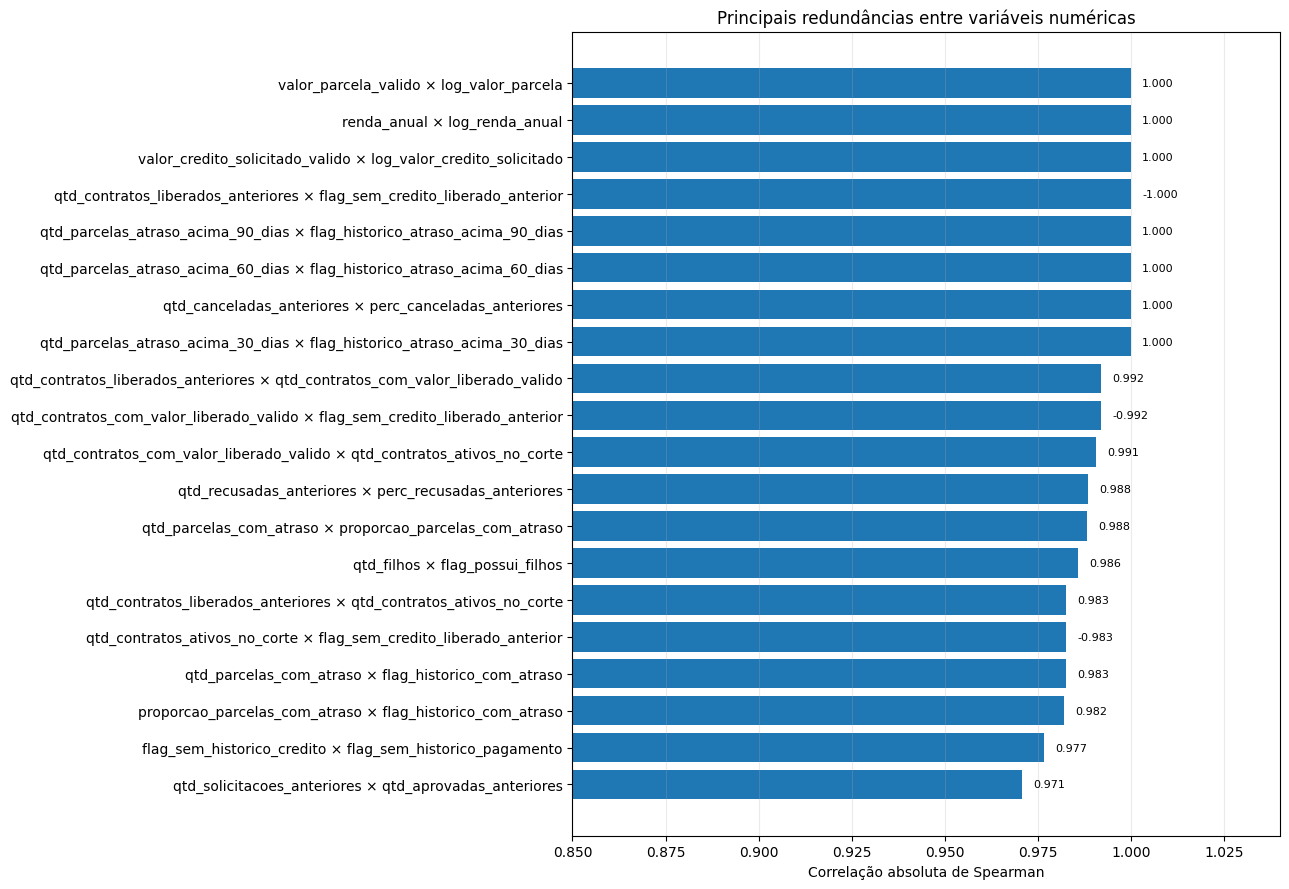

In [22]:
top_pares_correlacionados = pares_correlacionados.nlargest(20, "correlacao_absoluta").copy()
top_pares_correlacionados["par"] = (
    top_pares_correlacionados["variavel_1"]
    + " × "
    + top_pares_correlacionados["variavel_2"]
)
dados_grafico = top_pares_correlacionados.sort_values("correlacao_absoluta").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, max(8, len(dados_grafico) * 0.45)))
barras = ax.barh(dados_grafico["par"], dados_grafico["correlacao_absoluta"])
for barra, correlacao in zip(barras, dados_grafico["correlacao"]):
    ax.text(
        barra.get_width() + 0.003,
        barra.get_y() + barra.get_height() / 2,
        f"{correlacao:.3f}",
        va="center",
        fontsize=8
    )
ax.set_title("Principais redundâncias entre variáveis numéricas")
ax.set_xlabel("Correlação absoluta de Spearman")
ax.set_ylabel("")
ax.set_xlim(0.85, 1.04)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### 5.6 Grupos de redundância e representantes

In [23]:
LIMITE_DUPLICIDADE = 0.95
pares_duplicidade = pares_correlacionados[
    pares_correlacionados["correlacao_absoluta"] >= LIMITE_DUPLICIDADE
].copy()

grafo_correlacao = {}
for _, linha in pares_duplicidade.iterrows():
    variavel_1, variavel_2 = linha["variavel_1"], linha["variavel_2"]
    grafo_correlacao.setdefault(variavel_1, set()).add(variavel_2)
    grafo_correlacao.setdefault(variavel_2, set()).add(variavel_1)

grupos_redundancia, visitadas = [], set()
for variavel in sorted(grafo_correlacao):
    if variavel in visitadas:
        continue
    grupo, pilha = set(), [variavel]
    while pilha:
        atual = pilha.pop()
        if atual in visitadas:
            continue
        visitadas.add(atual)
        grupo.add(atual)
        pilha.extend(grafo_correlacao.get(atual, set()) - visitadas)
    grupos_redundancia.append(sorted(grupo))

grupos_redundancia = sorted(grupos_redundancia, key=lambda grupo: grupo[0])
print(f"Grupos de redundância com |correlação| >= {LIMITE_DUPLICIDADE}: {len(grupos_redundancia)}")
for numero, grupo in enumerate(grupos_redundancia, start=1):
    print(f"Grupo {numero}: {grupo}")

Grupos de redundância com |correlação| >= 0.95: 13
Grupo 1: ['flag_historico_atraso_acima_30_dias', 'qtd_parcelas_atraso_acima_30_dias']
Grupo 2: ['flag_historico_atraso_acima_60_dias', 'qtd_parcelas_atraso_acima_60_dias']
Grupo 3: ['flag_historico_atraso_acima_90_dias', 'qtd_parcelas_atraso_acima_90_dias']
Grupo 4: ['flag_historico_com_atraso', 'proporcao_parcelas_com_atraso', 'qtd_parcelas_com_atraso']
Grupo 5: ['flag_possui_filhos', 'qtd_filhos']
Grupo 6: ['flag_sem_credito_liberado_anterior', 'qtd_contratos_ativos_no_corte', 'qtd_contratos_com_valor_liberado_valido', 'qtd_contratos_liberados_anteriores']
Grupo 7: ['flag_sem_historico_credito', 'flag_sem_historico_pagamento']
Grupo 8: ['log_renda_anual', 'renda_anual']
Grupo 9: ['log_valor_credito_solicitado', 'valor_credito_solicitado_valido']
Grupo 10: ['log_valor_parcela', 'valor_parcela_valido']
Grupo 11: ['perc_canceladas_anteriores', 'qtd_canceladas_anteriores']
Grupo 12: ['perc_recusadas_anteriores', 'qtd_recusadas_anteriores

In [24]:
configuracao_redundancia = [
    {
        "membros": {"flag_sem_credito_liberado_anterior", "qtd_contratos_ativos_no_corte", "qtd_contratos_com_valor_liberado_valido", "qtd_contratos_liberados_anteriores"},
        "representante": "qtd_contratos_ativos_no_corte",
        "motivo": "Maior IV e associação com o target no grupo"
    },
    {
        "membros": {"log_valor_parcela", "valor_parcela_valido"},
        "representante": "log_valor_parcela",
        "motivo": "Versão log reduz assimetria e preserva a ordenação"
    },
    {
        "membros": {"log_valor_credito_solicitado", "valor_credito_solicitado_valido"},
        "representante": "log_valor_credito_solicitado",
        "motivo": "Versão log reduz assimetria e preserva o mesmo poder bivariado"
    },
    {
        "membros": {"log_renda_anual", "renda_anual"},
        "representante": "log_renda_anual",
        "motivo": "Versão log reduz a forte assimetria da renda"
    },
    {
        "membros": {"flag_historico_atraso_acima_90_dias", "qtd_parcelas_atraso_acima_90_dias"},
        "representante": "qtd_parcelas_atraso_acima_90_dias",
        "motivo": "Contagem preserva mais informação que a flag"
    },
    {
        "membros": {"flag_historico_atraso_acima_60_dias", "qtd_parcelas_atraso_acima_60_dias"},
        "representante": "qtd_parcelas_atraso_acima_60_dias",
        "motivo": "Contagem preserva mais informação que a flag"
    },
    {
        "membros": {"perc_canceladas_anteriores", "qtd_canceladas_anteriores"},
        "representante": "perc_canceladas_anteriores",
        "motivo": "Maior IV e medida relativa ao histórico"
    },
    {
        "membros": {"flag_historico_atraso_acima_30_dias", "qtd_parcelas_atraso_acima_30_dias"},
        "representante": "qtd_parcelas_atraso_acima_30_dias",
        "motivo": "Contagem preserva mais informação que a flag"
    },
    {
        "membros": {"flag_historico_com_atraso", "proporcao_parcelas_com_atraso", "qtd_parcelas_com_atraso"},
        "representante": "proporcao_parcelas_com_atraso",
        "motivo": "Maior IV, maior associação com o target e normalização pelo histórico"
    },
    {
        "membros": {"perc_recusadas_anteriores", "qtd_recusadas_anteriores"},
        "representante": "perc_recusadas_anteriores",
        "motivo": "Maior IV e medida relativa ao histórico"
    },
    {
        "membros": {"flag_possui_filhos", "qtd_filhos"},
        "representante": "qtd_filhos",
        "motivo": "Contagem contém a informação da flag e preserva maior granularidade"
    },
    {
        "membros": {"flag_sem_historico_credito", "flag_sem_historico_pagamento"},
        "representante": "flag_sem_historico_pagamento",
        "motivo": "Maior IV e associação com o target"
    },
    {
        "membros": {"qtd_aprovadas_anteriores", "qtd_parcelas_historicas", "qtd_solicitacoes_anteriores"},
        "representante": "qtd_solicitacoes_anteriores",
        "motivo": "IV semelhante, maior associação com o target e interpretação mais direta"
    }
]

config_por_grupo = {
    frozenset(item["membros"]): item
    for item in configuracao_redundancia
}

decisoes_redundancia_finais = []
for numero, grupo in enumerate(grupos_redundancia, start=1):
    chave = frozenset(grupo)
    configuracao = config_por_grupo.get(chave)

    if configuracao is None:
        ranking = pd.DataFrame({
            "variavel": grupo,
            "iv": [mapa_iv.get(v, 0) for v in grupo],
            "correlacao_abs_target": [mapa_correlacao_target.get(v, 0) for v in grupo],
            "perc_ausentes": [mapa_ausencia.get(v, 100) for v in grupo]
        }).sort_values(
            ["iv", "correlacao_abs_target", "perc_ausentes"],
            ascending=[False, False, True]
        )
        representante = ranking.iloc[0]["variavel"]
        motivo = "Escolha automática por IV, associação com o target e ausência"
    else:
        representante = configuracao["representante"]
        motivo = configuracao["motivo"]

    for variavel in grupo:
        decisoes_redundancia_finais.append({
            "grupo": numero,
            "variavel": variavel,
            "decisao": "MANTER" if variavel == representante else "EXCLUIR",
            "representante": representante,
            "motivo": motivo,
            "iv": mapa_iv.get(variavel),
            "correlacao_abs_target": mapa_correlacao_target.get(variavel),
            "perc_ausentes": mapa_ausencia.get(variavel)
        })

tabela_redundancia_final = (
    pd.DataFrame(decisoes_redundancia_finais)
    .sort_values(["grupo", "decisao"], ascending=[True, False])
    .reset_index(drop=True)
)

tabela_redundancia_final

,grupo,variavel,decisao,representante,motivo,iv,correlacao_abs_target,perc_ausentes
0,1,qtd_parcelas_atraso_acima_30_dias,MANTER,qtd_parcelas_atraso_acima_30_dias,Contagem preserva mais informação que a flag,0.021399,0.033256,0.0000
1,1,flag_historico_atraso_acima_30_dias,EXCLUIR,qtd_parcelas_atraso_acima_30_dias,Contagem preserva mais informação que a flag,0.020515,0.033177,0.0000
2,2,qtd_parcelas_atraso_acima_60_dias,MANTER,qtd_parcelas_atraso_acima_60_dias,Contagem preserva mais informação que a flag,0.017845,0.032664,0.0000
3,2,flag_historico_atraso_acima_60_dias,EXCLUIR,qtd_parcelas_atraso_acima_60_dias,Contagem preserva mais informação que a flag,0.017542,0.032672,0.0000
4,3,qtd_parcelas_atraso_acima_90_dias,MANTER,qtd_parcelas_atraso_acima_90_dias,Contagem preserva mais informação que a flag,0.014700,0.029249,0.0000
5,3,flag_historico_atraso_acima_90_dias,EXCLUIR,qtd_parcelas_atraso_acima_90_dias,Contagem preserva mais informação que a flag,0.014098,0.029265,0.0000
6,4,proporcao_parcelas_com_atraso,MANTER,proporcao_parcelas_com_atraso,"Maior IV, maior associação com o target e norm...",0.183635,0.084581,0.0000
7,4,flag_historico_com_atraso,EXCLUIR,proporcao_parcelas_com_atraso,"Maior IV, maior associação com o target e norm...",0.125934,0.074098,0.0000
8,4,qtd_parcelas_com_atraso,EXCLUIR,proporcao_parcelas_com_atraso,"Maior IV, maior associação com o target e norm...",0.150716,0.080310,0.0000
9,5,qtd_filhos,MANTER,qtd_filhos,Contagem contém a informação da flag e preserv...,0.003379,0.000007,0.0000


In [25]:
variaveis_excluidas_redundancia = set(
    tabela_redundancia_final.loc[
        tabela_redundancia_final["decisao"] == "EXCLUIR",
        "variavel"
    ]
)

colunas_features_pos_redundancia = [
    coluna for coluna in colunas_features_pos_qualidade
    if coluna not in variaveis_excluidas_redundancia
]

print(f"Features após qualidade: {len(colunas_features_pos_qualidade)}")
print(f"Features excluídas por redundância: {len(variaveis_excluidas_redundancia)}")
print(f"Features após redundância: {len(colunas_features_pos_redundancia)}")

Features após qualidade: 60
Features excluídas por redundância: 17
Features após redundância: 43


### 5.7 Conjunto comum de variáveis pré-selecionadas

A seleção partiu de 72 features candidatas.

Foram excluídas 12 variáveis por baixa qualidade, combinando ausência ou concentração excessiva com Information Value inferior a 0,02. Em seguida, 17 variáveis foram removidas por redundância forte, preservando uma representante de cada grupo com correlação absoluta igual ou superior a 0,95.

O conjunto comum pré-selecionado contém 43 features. Essas variáveis serão disponibilizadas aos três algoritmos, mantendo uma base comparável entre os modelos.

A seleção ainda não está encerrada. A regressão logística utilizará regularização L1, enquanto os modelos baseados em árvores serão avaliados por importância e contribuição multivariada. Teste e out-of-time permanecem fora das decisões de seleção.

## 6. Pré-processamento final e regressão logística baseline

As 43 features pré-selecionadas compõem o conjunto comum inicial dos algoritmos. O pré-processamento permanece dentro do pipeline para ser reajustado em cada fold da validação cruzada, evitando leakage.

In [26]:
colunas_modelo_base = colunas_features_pos_redundancia
colunas_numericas_modelo = [c for c in colunas_modelo_base if c in colunas_numericas]
colunas_categoricas_modelo = [c for c in colunas_modelo_base if c in colunas_categoricas]

# A ausência de log_valor_credito_solicitado já é representada pela flag explícita.
flag_explicita = X_treino["flag_valor_credito_solicitado_indisponivel"].astype(int)
flag_ausencia = X_treino["log_valor_credito_solicitado"].isna().astype(int)
perc_igualdade_flags = (flag_explicita == flag_ausencia).mean() * 100
if not np.isclose(perc_igualdade_flags, 100.0):
    raise ValueError("A flag explícita não coincide integralmente com a ausência do valor solicitado.")

colunas_ausencia_modelo = [
    coluna for coluna in colunas_numericas_com_ausencia
    if coluna in colunas_numericas_modelo
    and coluna != "log_valor_credito_solicitado"
]
colunas_winsorizacao_modelo = [
    coluna for coluna in colunas_winsorizacao_direita
    if coluna in colunas_numericas_modelo
]

X_treino_modelo = pdf_treino[colunas_modelo_base].copy()
X_teste_modelo = pdf_teste[colunas_modelo_base].copy()
X_out_of_time_modelo = pdf_out_of_time[colunas_modelo_base].copy()
X_scoring_modelo = pdf_scoring[colunas_modelo_base].copy()

print(f"Features comuns: {len(colunas_modelo_base)}")
print(f"Numéricas: {len(colunas_numericas_modelo)}")
print(f"Categóricas: {len(colunas_categoricas_modelo)}")
print(f"Numéricas com indicador de ausência: {len(colunas_ausencia_modelo)}")
print(f"Numéricas com winsorização: {len(colunas_winsorizacao_modelo)}")
print(f"Igualdade entre a flag explícita e a ausência correspondente: {perc_igualdade_flags:.4f}%")

Features comuns: 43
Numéricas: 32
Categóricas: 11
Numéricas com indicador de ausência: 8
Numéricas com winsorização: 6
Igualdade entre a flag explícita e a ausência correspondente: 100.0000%


### 6.1 Transformadores locais e construção do pré-processamento

Para preservar a execução em ambiente genérico, os tratamentos de categorias raras, ausências e extremos são implementados no próprio notebook com a interface do `scikit-learn`.

Os parâmetros são aprendidos exclusivamente no conjunto recebido pelo método `fit`. Como os transformadores permanecem dentro do `Pipeline`, cada fold da validação cruzada reajusta o pré-processamento somente com seus dados de treino, evitando vazamento de informação.


In [27]:
class CategoricalImputer(BaseEstimator, TransformerMixin):
    """Preenche ausências categóricas preservando a saída como DataFrame."""

    def __init__(self, fill_value="__AUSENTE__", variables=None):
        self.fill_value = fill_value
        self.variables = variables

    def fit(self, X, y=None):
        self.variables_ = list(self.variables or [])
        return self

    def transform(self, X):
        X = X.copy()
        for coluna in self.variables_:
            X[coluna] = X[coluna].astype("object").where(
                X[coluna].notna(), self.fill_value
            )
        return X


class RareLabelEncoder(BaseEstimator, TransformerMixin):
    """Agrupa categorias raras com frequências aprendidas somente no treino."""

    def __init__(
        self,
        tol=0.005,
        n_categories=1,
        replace_with="__OUTROS__",
        variables=None
    ):
        self.tol = tol
        self.n_categories = n_categories
        self.replace_with = replace_with
        self.variables = variables

    def fit(self, X, y=None):
        self.variables_ = list(self.variables or [])
        self.categorias_frequentes_ = {}

        for coluna in self.variables_:
            serie = X[coluna].astype("object")

            if serie.nunique(dropna=False) > self.n_categories:
                frequencias = serie.value_counts(normalize=True, dropna=False)
                categorias = frequencias[frequencias >= self.tol].index
                self.categorias_frequentes_[coluna] = set(categorias.tolist())
            else:
                self.categorias_frequentes_[coluna] = set(
                    serie.drop_duplicates().tolist()
                )

        return self

    def transform(self, X):
        X = X.copy()

        for coluna in self.variables_:
            frequentes = self.categorias_frequentes_[coluna]
            X[coluna] = X[coluna].astype("object").where(
                X[coluna].isin(frequentes), self.replace_with
            )

        return X


class AddMissingIndicator(BaseEstimator, TransformerMixin):
    """Cria flags de ausência para as variáveis definidas no treino."""

    def __init__(self, variables=None, missing_only=True):
        self.variables = variables
        self.missing_only = missing_only

    def fit(self, X, y=None):
        candidatas = list(self.variables or [])
        self.variables_ = (
            [coluna for coluna in candidatas if X[coluna].isna().any()]
            if self.missing_only
            else candidatas
        )
        return self

    def transform(self, X):
        X = X.copy()

        for coluna in self.variables_:
            X[f"{coluna}_na"] = X[coluna].isna().astype("int8")

        return X


class Winsorizer(BaseEstimator, TransformerMixin):
    """Limita a cauda superior pelos quantis aprendidos somente no treino."""

    def __init__(self, fold=0.01, variables=None):
        self.fold = fold
        self.variables = variables

    def fit(self, X, y=None):
        self.variables_ = list(self.variables or [])
        self.limites_superiores_ = {
            coluna: pd.to_numeric(X[coluna], errors="coerce").quantile(
                1 - self.fold
            )
            for coluna in self.variables_
        }
        return self

    def transform(self, X):
        X = X.copy()

        for coluna, limite in self.limites_superiores_.items():
            if pd.notna(limite):
                X[coluna] = pd.to_numeric(
                    X[coluna], errors="coerce"
                ).clip(upper=limite)

        return X


class MedianImputer(BaseEstimator, TransformerMixin):
    """Imputa variáveis numéricas pela mediana aprendida somente no treino."""

    def __init__(self, variables=None):
        self.variables = variables

    def fit(self, X, y=None):
        self.variables_ = list(self.variables or [])
        self.medianas_ = {}

        for coluna in self.variables_:
            mediana = pd.to_numeric(X[coluna], errors="coerce").median()
            self.medianas_[coluna] = 0.0 if pd.isna(mediana) else float(mediana)

        return self

    def transform(self, X):
        X = X.copy()

        for coluna, mediana in self.medianas_.items():
            X[coluna] = pd.to_numeric(
                X[coluna], errors="coerce"
            ).fillna(mediana)

        return X


In [28]:
def construir_preprocessamento(
    colunas_categoricas,
    colunas_numericas,
    colunas_ausencia,
    colunas_winsorizacao
):
    etapas = []

    if colunas_categoricas:
        etapas.extend([
            (
                "imputacao_categoricas",
                CategoricalImputer(
                    fill_value="__AUSENTE__",
                    variables=colunas_categoricas
                )
            ),
            (
                "agrupamento_categorias_raras",
                RareLabelEncoder(
                    tol=0.005,
                    n_categories=1,
                    replace_with="__OUTROS__",
                    variables=colunas_categoricas
                )
            )
        ])

    if colunas_ausencia:
        etapas.append((
            "indicadores_ausencia",
            AddMissingIndicator(variables=colunas_ausencia, missing_only=True)
        ))

    if colunas_winsorizacao:
        etapas.append((
            "winsorizacao",
            Winsorizer(
                fold=0.01,
                variables=colunas_winsorizacao
            )
        ))

    etapas.extend([
        (
            "imputacao_numericas",
            MedianImputer(variables=colunas_numericas)
        ),
        (
            "codificacao",
            ColumnTransformer(
                transformers=[
                    ("numericas", StandardScaler(), make_column_selector(dtype_include=np.number)),
                    ("categoricas", OneHotEncoder(handle_unknown="ignore"), make_column_selector(dtype_exclude=np.number))
                ],
                remainder="drop"
            )
        )
    ])
    return Pipeline(etapas)

preprocessamento_modelo = construir_preprocessamento(
    colunas_categoricas_modelo,
    colunas_numericas_modelo,
    colunas_ausencia_modelo,
    colunas_winsorizacao_modelo
)

print("Pré-processamento final configurado para as 43 features.")

Pré-processamento final configurado para as 43 features.


### 6.2 Validação cruzada da regressão logística

A regressão logística é a baseline interpretável. A penalização L1 realiza seleção embarcada e a validação cruzada é estratificada e agrupada por cliente. Uma única busca compacta avalia a região de regularização que apresentou melhor generalização.

In [29]:
cv_grupos = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEMENTE)

pipeline_logistica = Pipeline([
    ("preprocessamento", clone(preprocessamento_modelo)),
    (
        "modelo",
        LogisticRegression(
            l1_ratio=1.0,
            solver="saga",
            class_weight="balanced",
            max_iter=1500,
            tol=1e-3,
            random_state=SEMENTE
        )
    )
])

busca_logistica = GridSearchCV(
    estimator=pipeline_logistica,
    param_grid={"modelo__C": [0.003, 0.01, 0.03, 0.10]},
    scoring="roc_auc",
    cv=cv_grupos,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    verbose=1
)

busca_logistica.fit(X_treino_modelo, y_treino, groups=grupos_treino)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__C': [0.003, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [30]:
resultado_cv_logistica = (
    pd.DataFrame(busca_logistica.cv_results_)[
        [
            "param_modelo__C", "mean_train_score", "mean_test_score",
            "std_test_score", "mean_fit_time"
        ]
    ]
    .rename(columns={
        "param_modelo__C": "C",
        "mean_train_score": "auc_treino_cv",
        "mean_test_score": "auc_validacao_cv",
        "std_test_score": "desvio_auc_validacao",
        "mean_fit_time": "tempo_medio_ajuste"
    })
    .astype({"C": float})
    .sort_values("auc_validacao_cv", ascending=False)
    .reset_index(drop=True)
)

# Entre resultados praticamente equivalentes, prioriza-se o menor C.
TOLERANCIA_AUC_PARCIMONIA = 0.0005
melhor_auc_cv = resultado_cv_logistica["auc_validacao_cv"].max()
candidatos_equivalentes = resultado_cv_logistica[
    resultado_cv_logistica["auc_validacao_cv"] >= melhor_auc_cv - TOLERANCIA_AUC_PARCIMONIA
]
C_FINAL_LOGISTICA = candidatos_equivalentes["C"].min()

print(f"Melhor AUC média observada: {melhor_auc_cv:.4f}")
print(f"C final selecionado por equivalência e parcimônia: {C_FINAL_LOGISTICA}")
resultado_cv_logistica

Melhor AUC média observada: 0.6628
C final selecionado por equivalência e parcimônia: 0.01


,C,auc_treino_cv,auc_validacao_cv,desvio_auc_validacao,tempo_medio_ajuste
0,0.010,0.676782,0.662800,0.011688,22.600600
1,0.030,0.683269,0.660767,0.011444,27.098133
2,0.003,0.666734,0.659405,0.010967,15.590194
3,0.100,0.686545,0.658162,0.011157,30.891921


**Critério de escolha do `C`**

A maior AUC média não é interpretada isoladamente na quarta casa decimal. Entre candidatos com diferença de AUC inferior a 0,0005, é escolhido o menor `C`, correspondente à regularização mais forte e ao modelo mais parcimonioso.

In [31]:
modelo_logistica_final = Pipeline([
    ("preprocessamento", clone(preprocessamento_modelo)),
    (
        "modelo",
        LogisticRegression(
            l1_ratio=1.0,
            solver="saga",
            C=C_FINAL_LOGISTICA,
            class_weight="balanced",
            max_iter=1500,
            tol=1e-3,
            random_state=SEMENTE
        )
    )
])

modelo_logistica_final.fit(X_treino_modelo, y_treino)
print(f"Regressão logística final ajustada com C = {C_FINAL_LOGISTICA}.")

Regressão logística final ajustada com C = 0.01.


### 6.3 Coeficientes e seleção multivariada

In [32]:
preprocessamento_final = modelo_logistica_final.named_steps["preprocessamento"]
codificacao_final = preprocessamento_final.named_steps["codificacao"]
modelo_final = modelo_logistica_final.named_steps["modelo"]

numericas_transformadas = list(codificacao_final.transformers_[0][2])
categoricas_transformadas = list(codificacao_final.transformers_[1][2])
one_hot_final = codificacao_final.named_transformers_["categoricas"]
colunas_one_hot = list(one_hot_final.get_feature_names_out(categoricas_transformadas))

nomes_features_transformadas = (
    [f"numerica__{coluna}" for coluna in numericas_transformadas]
    + [f"categorica__{coluna}" for coluna in colunas_one_hot]
)

if any("log_valor_credito_solicitado_na" in nome for nome in nomes_features_transformadas):
    raise ValueError("O indicador de ausência duplicado ainda está presente no pipeline.")

coeficientes_logistica = pd.DataFrame({
    "feature_transformada": nomes_features_transformadas,
    "coeficiente": modelo_final.coef_[0]
})
coeficientes_logistica["coeficiente_absoluto"] = coeficientes_logistica["coeficiente"].abs()
coeficientes_logistica["selecionada_l1"] = coeficientes_logistica["coeficiente_absoluto"] > 1e-8

print(f"Features transformadas: {len(coeficientes_logistica)}")
print(f"Coeficientes diferentes de zero: {coeficientes_logistica['selecionada_l1'].sum()}")
print(f"Coeficientes zerados pela L1: {(~coeficientes_logistica['selecionada_l1']).sum()}")

Features transformadas: 124
Coeficientes diferentes de zero: 43
Coeficientes zerados pela L1: 81


In [33]:
def identificar_feature_original(feature_transformada):
    nome = feature_transformada.split("__", 1)[1]
    if nome in colunas_modelo_base:
        return nome
    for coluna in sorted(colunas_modelo_base, key=len, reverse=True):
        if nome.startswith(f"{coluna}_"):
            return coluna
    return nome

coeficientes_logistica["variavel_original"] = (
    coeficientes_logistica["feature_transformada"].apply(identificar_feature_original)
)

pesos_logistica = coeficientes_logistica[coeficientes_logistica["selecionada_l1"]].copy()
pesos_logistica["direcao"] = np.where(
    pesos_logistica["coeficiente"] > 0,
    "AUMENTA_RISCO",
    "REDUZ_RISCO"
)
pesos_logistica["odds_ratio"] = np.exp(pesos_logistica["coeficiente"])
pesos_logistica = pesos_logistica[
    [
        "variavel_original", "feature_transformada", "coeficiente",
        "coeficiente_absoluto", "odds_ratio", "direcao"
    ]
].sort_values("coeficiente_absoluto", ascending=False).reset_index(drop=True)

ranking_variaveis_logistica = (
    coeficientes_logistica.groupby("variavel_original", as_index=False)
    .agg(
        qtd_componentes=("feature_transformada", "size"),
        qtd_componentes_ativos=("selecionada_l1", "sum"),
        peso_total_absoluto=("coeficiente_absoluto", "sum"),
        maior_peso_absoluto=("coeficiente_absoluto", "max"),
        menor_coeficiente=("coeficiente", "min"),
        maior_coeficiente=("coeficiente", "max")
    )
)
ranking_variaveis_logistica["selecionada_l1"] = ranking_variaveis_logistica["qtd_componentes_ativos"] > 0
ranking_variaveis_logistica = ranking_variaveis_logistica.sort_values(
    ["selecionada_l1", "maior_peso_absoluto"],
    ascending=[False, False]
).reset_index(drop=True)

print(f"Variáveis originais avaliadas: {len(ranking_variaveis_logistica)}")
print(f"Variáveis com contribuição na logística: {ranking_variaveis_logistica['selecionada_l1'].sum()}")
print(f"Variáveis totalmente zeradas: {(~ranking_variaveis_logistica['selecionada_l1']).sum()}")
pesos_logistica.head(30)

Variáveis originais avaliadas: 43
Variáveis com contribuição na logística: 31
Variáveis totalmente zeradas: 12


,variavel_original,feature_transformada,coeficiente,coeficiente_absoluto,odds_ratio,direcao
0,tipo_contrato,categorica__tipo_contrato_Consumer loans,-0.710439,0.710439,0.491428,REDUZ_RISCO
1,proporcao_parcelas_com_atraso,numerica__proporcao_parcelas_com_atraso,0.366606,0.366606,1.442830,AUMENTA_RISCO
2,tipo_contrato,categorica__tipo_contrato_Revolving loans,0.211500,0.211500,1.235530,AUMENTA_RISCO
3,tipo_organizacao,categorica__tipo_organizacao_Business Entity T...,-0.154233,0.154233,0.857072,REDUZ_RISCO
4,dias_desde_ultima_aprovacao,numerica__dias_desde_ultima_aprovacao,-0.143632,0.143632,0.866206,REDUZ_RISCO
5,log_valor_credito_solicitado,numerica__log_valor_credito_solicitado,-0.141645,0.141645,0.867929,REDUZ_RISCO
6,tipo_organizacao,categorica__tipo_organizacao_XNA,0.106963,0.106963,1.112893,AUMENTA_RISCO
7,dia_semana_solicitacao,categorica__dia_semana_solicitacao_TUESDAY,-0.088616,0.088616,0.915197,REDUZ_RISCO
8,idade_avaliacao,numerica__idade_avaliacao,-0.086123,0.086123,0.917482,REDUZ_RISCO
9,log_valor_parcela,numerica__log_valor_parcela_na,-0.079264,0.079264,0.923796,REDUZ_RISCO


In [34]:
ranking_variaveis_logistica

,variavel_original,qtd_componentes,qtd_componentes_ativos,peso_total_absoluto,maior_peso_absoluto,menor_coeficiente,maior_coeficiente,selecionada_l1
0,tipo_contrato,3,2,0.921939,0.710439,-0.710439,0.211500,True
1,proporcao_parcelas_com_atraso,1,1,0.366606,0.366606,0.366606,0.366606,True
2,tipo_organizacao,30,4,0.300580,0.154233,-0.154233,0.106963,True
3,dias_desde_ultima_aprovacao,2,2,0.171510,0.143632,-0.143632,0.027878,True
4,log_valor_credito_solicitado,1,1,0.141645,0.141645,-0.141645,-0.141645,True
5,dia_semana_solicitacao,7,4,0.211447,0.088616,-0.088616,0.067548,True
6,idade_avaliacao,1,1,0.086123,0.086123,-0.086123,-0.086123,True
7,log_valor_parcela,2,1,0.079264,0.079264,-0.079264,0.000000,True
8,razao_parcela_credito,2,2,0.120542,0.071697,0.048844,0.071697,True
9,possui_imovel,2,1,0.069543,0.069543,0.000000,0.069543,True


A seleção da regressão logística representa contribuição **linear e incremental**. As variáveis zeradas não serão automaticamente retiradas dos modelos baseados em árvores, que podem explorar relações não lineares e interações. Os challengers iniciarão com as mesmas 43 features comuns.

### 6.4 Performance da baseline no treino e no teste

In [35]:
def calcular_ks(y_real, probabilidade):
    fpr, tpr, _ = roc_curve(y_real, probabilidade)
    return np.max(tpr - fpr)


prob_treino_logistica = modelo_logistica_final.predict_proba(X_treino_modelo)[:, 1]
prob_teste_logistica = modelo_logistica_final.predict_proba(X_teste_modelo)[:, 1]

metricas_logistica = pd.DataFrame([
    {
        "amostra": "TREINO",
        "auc": roc_auc_score(y_treino, prob_treino_logistica),
        "gini": 2 * roc_auc_score(y_treino, prob_treino_logistica) - 1,
        "ks": calcular_ks(y_treino, prob_treino_logistica),
        "pr_auc": average_precision_score(y_treino, prob_treino_logistica)
    },
    {
        "amostra": "TESTE",
        "auc": roc_auc_score(y_teste, prob_teste_logistica),
        "gini": 2 * roc_auc_score(y_teste, prob_teste_logistica) - 1,
        "ks": calcular_ks(y_teste, prob_teste_logistica),
        "pr_auc": average_precision_score(y_teste, prob_teste_logistica)
    }
])

metricas_logistica.round(4)

,amostra,auc,gini,ks,pr_auc
0,TREINO,0.6760,0.3519,0.2679,0.0860
1,TESTE,0.6483,0.2966,0.2368,0.0754


**Leitura da baseline**

A regressão logística é avaliada por discriminação e estabilidade. Como foi utilizada ponderação balanceada das classes, as saídas brutas servem inicialmente para ordenação de risco; a calibração será realizada somente após a seleção do modelo.

O out-of-time permanece intocado nesta etapa e será utilizado apenas na validação temporal final do modelo selecionado.


## 7. Modelos não lineares e comparação de challengers

A regressão logística foi utilizada como baseline interpretável. Nesta etapa, Random Forest e Histogram-based Gradient Boosting são avaliados como challengers capazes de representar relações não lineares e interações.

Os três algoritmos utilizam as mesmas 43 features pré-selecionadas. A escolha permanece restrita à validação cruzada estratificada e agrupada por cliente; teste e out-of-time não participam da seleção do algoritmo.


### 7.1 Random Forest

A Random Forest é avaliada com três configurações controladas de profundidade, tamanho mínimo de folha e amostragem. O objetivo é verificar se relações não lineares produzem ganho consistente sem sobreajuste relevante.


**Busca de hiperparâmetros**

In [36]:
preprocessamento_random_forest = clone(preprocessamento_modelo)
preprocessamento_random_forest.set_params(codificacao__numericas="passthrough")

pipeline_random_forest = Pipeline([
    ("preprocessamento", preprocessamento_random_forest),
    (
        "modelo",
        RandomForestClassifier(
            n_estimators=150,
            class_weight="balanced_subsample",
            bootstrap=True,
            random_state=SEMENTE,
            n_jobs=1
        )
    )
])

parametros_random_forest = [
    {
        "modelo__max_depth": [6],
        "modelo__min_samples_leaf": [100],
        "modelo__max_features": ["sqrt"],
        "modelo__max_samples": [0.70]
    },
    {
        "modelo__max_depth": [10],
        "modelo__min_samples_leaf": [50],
        "modelo__max_features": [0.30],
        "modelo__max_samples": [0.85]
    },
    {
        "modelo__max_depth": [14],
        "modelo__min_samples_leaf": [20],
        "modelo__max_features": [0.50],
        "modelo__max_samples": [1.00]
    }
]

busca_random_forest = GridSearchCV(
    pipeline_random_forest,
    parametros_random_forest,
    scoring="roc_auc",
    cv=cv_grupos,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    verbose=2
)
busca_random_forest.fit(X_treino_modelo, y_treino, groups=grupos_treino)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'modelo__max_depth': [6], 'modelo__max_features': ['sqrt'], 'modelo__max_samples': [0.7], 'modelo__min_samples_leaf': [100]}, {'modelo__max_depth': [10], 'modelo__max_features': [0.3], 'modelo__max_samples': [0.85], 'modelo__min_samples_leaf': [50]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-f

**Resultado da validação interna**

In [37]:
resultado_cv_random_forest = (
    pd.DataFrame(busca_random_forest.cv_results_)[[
        "param_modelo__max_depth", "param_modelo__min_samples_leaf",
        "param_modelo__max_features", "param_modelo__max_samples",
        "mean_train_score", "mean_test_score", "std_test_score", "mean_fit_time"
    ]]
    .rename(columns={
        "param_modelo__max_depth": "max_depth",
        "param_modelo__min_samples_leaf": "min_samples_leaf",
        "param_modelo__max_features": "max_features",
        "param_modelo__max_samples": "max_samples",
        "mean_train_score": "auc_treino_cv",
        "mean_test_score": "auc_validacao_cv",
        "std_test_score": "desvio_auc_validacao",
        "mean_fit_time": "tempo_medio_ajuste"
    })
)

resultado_cv_random_forest["gap_treino_validacao"] = (
    resultado_cv_random_forest["auc_treino_cv"]
    - resultado_cv_random_forest["auc_validacao_cv"]
)
resultado_cv_random_forest["classificacao_gap"] = pd.cut(
    resultado_cv_random_forest["gap_treino_validacao"],
    bins=[-np.inf, 0.03, 0.05, np.inf],
    labels=["CONTROLADO", "ATENCAO", "SOBREAJUSTE"]
)
resultado_cv_random_forest = resultado_cv_random_forest.sort_values(
    "auc_validacao_cv", ascending=False
).reset_index(drop=True)

print(f"Melhor AUC média: {busca_random_forest.best_score_:.4f}")
print("Melhores parâmetros:", busca_random_forest.best_params_)
resultado_cv_random_forest

Melhor AUC média: 0.6629
Melhores parâmetros: {'modelo__max_depth': 10, 'modelo__max_features': 0.3, 'modelo__max_samples': 0.85, 'modelo__min_samples_leaf': 50}


,max_depth,min_samples_leaf,max_features,max_samples,auc_treino_cv,auc_validacao_cv,desvio_auc_validacao,tempo_medio_ajuste,gap_treino_validacao,classificacao_gap
0,10,50,0.3,0.85,0.828507,0.662923,0.011693,32.646417,0.165584,SOBREAJUSTE
1,6,100,sqrt,0.70,0.713762,0.661556,0.009186,9.570282,0.052206,SOBREAJUSTE
2,14,20,0.5,1.00,0.960070,0.643558,0.011938,52.749743,0.316512,SOBREAJUSTE


**Resultado e decisão sobre a Random Forest**

As configurações avaliadas apresentaram diferenças relevantes entre a AUC de treino e a AUC de validação cruzada.

A configuração com maior AUC de validação alcançou 0,6573, resultado ligeiramente inferior à regressão logística, mas apresentou gap de aproximadamente 0,17 em relação ao treino, evidenciando sobreajuste.

A configuração mais conservadora reduziu o gap para aproximadamente 0,05, porém sua AUC de validação caiu para 0,6521, permanecendo inferior à baseline.

Diante da ausência de ganho preditivo e do aumento de complexidade, a Random Forest não seguirá para avaliação na amostra de teste. A decisão evita utilizar o teste como instrumento de seleção de um modelo que já apresentou instabilidade na validação interna.


### 7.2 Histogram-based Gradient Boosting

O Histogram-based Gradient Boosting é avaliado como segundo challenger por capturar relações não lineares com implementação nativa do `scikit-learn`. Três configurações conservadoras são comparadas exclusivamente na validação cruzada agrupada.


**Pré-processamento para o boosting**

In [38]:
try:
    one_hot_denso = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_denso = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessamento_hist_gradient = clone(preprocessamento_modelo)
preprocessamento_hist_gradient.set_params(
    codificacao__numericas="passthrough",
    codificacao__categoricas=one_hot_denso
)
pesos_treino = compute_sample_weight(class_weight="balanced", y=y_treino)

**Pipeline e busca controlada**

In [39]:
pipeline_hist_gradient = Pipeline([
    ("preprocessamento", preprocessamento_hist_gradient),
    (
        "modelo",
        HistGradientBoostingClassifier(
            loss="log_loss",
            early_stopping=False,
            random_state=SEMENTE
        )
    )
])

parametros_hist_gradient = [
    {
        "modelo__learning_rate": [0.05],
        "modelo__max_iter": [150],
        "modelo__max_leaf_nodes": [7],
        "modelo__min_samples_leaf": [100],
        "modelo__l2_regularization": [10.0]
    },
    {
        "modelo__learning_rate": [0.05],
        "modelo__max_iter": [150],
        "modelo__max_leaf_nodes": [15],
        "modelo__min_samples_leaf": [50],
        "modelo__l2_regularization": [5.0]
    },
    {
        "modelo__learning_rate": [0.03],
        "modelo__max_iter": [200],
        "modelo__max_leaf_nodes": [31],
        "modelo__min_samples_leaf": [50],
        "modelo__l2_regularization": [10.0]
    }
]

busca_hist_gradient = GridSearchCV(
    estimator=pipeline_hist_gradient,
    param_grid=parametros_hist_gradient,
    scoring="roc_auc",
    cv=cv_grupos,
    n_jobs=1,
    refit=True,
    return_train_score=True,
    verbose=2
)

busca_hist_gradient.fit(
    X_treino_modelo,
    y_treino,
    groups=grupos_treino,
    modelo__sample_weight=pesos_treino
);

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END modelo__l2_regularization=10.0, modelo__learning_rate=0.05, modelo__max_iter=150, modelo__max_leaf_nodes=7, modelo__min_samples_leaf=100; total time=   4.5s
[CV] END modelo__l2_regularization=10.0, modelo__learning_rate=0.05, modelo__max_iter=150, modelo__max_leaf_nodes=7, modelo__min_samples_leaf=100; total time=   2.0s
[CV] END modelo__l2_regularization=10.0, modelo__learning_rate=0.05, modelo__max_iter=150, modelo__max_leaf_nodes=7, modelo__min_samples_leaf=100; total time=   1.8s
[CV] END modelo__l2_regularization=5.0, modelo__learning_rate=0.05, modelo__max_iter=150, modelo__max_leaf_nodes=15, modelo__min_samples_leaf=50; total time=   2.7s
[CV] END modelo__l2_regularization=5.0, modelo__learning_rate=0.05, modelo__max_iter=150, modelo__max_leaf_nodes=15, modelo__min_samples_leaf=50; total time=   2.6s
[CV] END modelo__l2_regularization=5.0, modelo__learning_rate=0.05, modelo__max_iter=150, modelo__max_leaf_nodes=

**Resultado da validação interna**

In [40]:
resultado_cv_hist_gradient = (
    pd.DataFrame(busca_hist_gradient.cv_results_)[
        [
            "param_modelo__learning_rate",
            "param_modelo__max_iter",
            "param_modelo__max_leaf_nodes",
            "param_modelo__min_samples_leaf",
            "param_modelo__l2_regularization",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "mean_fit_time"
        ]
    ]
    .rename(columns={
        "param_modelo__learning_rate": "learning_rate",
        "param_modelo__max_iter": "max_iter",
        "param_modelo__max_leaf_nodes": "max_leaf_nodes",
        "param_modelo__min_samples_leaf": "min_samples_leaf",
        "param_modelo__l2_regularization": "l2_regularization",
        "mean_train_score": "auc_treino_cv",
        "mean_test_score": "auc_validacao_cv",
        "std_test_score": "desvio_auc_validacao",
        "mean_fit_time": "tempo_medio_ajuste"
    })
)

resultado_cv_hist_gradient["gap_treino_validacao"] = (
    resultado_cv_hist_gradient["auc_treino_cv"]
    - resultado_cv_hist_gradient["auc_validacao_cv"]
)

resultado_cv_hist_gradient["classificacao_gap"] = pd.cut(
    resultado_cv_hist_gradient["gap_treino_validacao"],
    bins=[-np.inf, 0.03, 0.05, np.inf],
    labels=["CONTROLADO", "ATENCAO", "SOBREAJUSTE"]
)

resultado_cv_hist_gradient = (
    resultado_cv_hist_gradient
    .sort_values("auc_validacao_cv", ascending=False)
    .reset_index(drop=True)
)

print(f"Melhor AUC média: {busca_hist_gradient.best_score_:.4f}")
print("Melhores parâmetros:")
print(busca_hist_gradient.best_params_)

resultado_cv_hist_gradient

Melhor AUC média: 0.6664
Melhores parâmetros:
{'modelo__l2_regularization': 10.0, 'modelo__learning_rate': 0.05, 'modelo__max_iter': 150, 'modelo__max_leaf_nodes': 7, 'modelo__min_samples_leaf': 100}


,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,auc_treino_cv,auc_validacao_cv,desvio_auc_validacao,tempo_medio_ajuste,gap_treino_validacao,classificacao_gap
0,0.05,150,7,100,10.0,0.734128,0.666378,0.012152,2.489198,0.067750,SOBREAJUSTE
1,0.05,150,15,50,5.0,0.808149,0.664879,0.011651,2.343479,0.143270,SOBREAJUSTE
2,0.03,200,31,50,10.0,0.863610,0.663833,0.011613,4.721296,0.199777,SOBREAJUSTE


**Resultado do Histogram-based Gradient Boosting**

A melhor configuração apresentou AUC média de validação de 0,6587, resultado praticamente equivalente ao da regressão logística. Entretanto, a diferença de aproximadamente 0,07 entre treino e validação indicou sobreajuste relevante.

Como o ganho nominal foi inferior à variabilidade entre os folds e não compensou o aumento de complexidade, o Histogram-based Gradient Boosting não avançará para a avaliação temporal final.


### 7.3 Comparação da validação interna e escolha do candidato

Os três algoritmos apresentaram capacidade discriminatória semelhante na validação cruzada, com AUC próxima de 0,66. Entretanto, os modelos baseados em árvores apresentaram diferenças substancialmente maiores entre treino e validação.

A Random Forest alcançou AUC de validação de 0,6573, mas apresentou gap de aproximadamente 0,17. A configuração mais conservadora reduziu o sobreajuste, porém também reduziu a AUC para 0,6521.

O Histogram-based Gradient Boosting apresentou a maior AUC nominal de validação, de 0,6587. Contudo, o ganho de aproximadamente 0,0006 sobre a regressão logística é inferior à variabilidade observada entre os folds e foi acompanhado por gap de aproximadamente 0,07.

A regressão logística apresentou resultado praticamente equivalente, menor diferença entre treino e validação e maior interpretabilidade. Por isso, foi selecionada como candidata à avaliação temporal final no out-of-time.

Os challengers não serão avaliados no teste ou no out-of-time, evitando utilizar essas amostras para tentar recuperar modelos que já apresentaram instabilidade na validação interna.


In [41]:
linha_logistica = resultado_cv_logistica[
    resultado_cv_logistica["C"] == C_FINAL_LOGISTICA
].iloc[0]
linha_random_forest = resultado_cv_random_forest.iloc[0]
linha_hist_gradient = resultado_cv_hist_gradient.iloc[0]

comparacao_validacao_interna = pd.DataFrame([
    {
        "modelo": "REGRESSAO_LOGISTICA",
        "configuracao": f"C={C_FINAL_LOGISTICA}",
        "auc_treino_cv": linha_logistica["auc_treino_cv"],
        "auc_validacao_cv": linha_logistica["auc_validacao_cv"],
        "desvio_auc_validacao": linha_logistica["desvio_auc_validacao"],
        "gap_treino_validacao": (
            linha_logistica["auc_treino_cv"] - linha_logistica["auc_validacao_cv"]
        ),
        "decisao": "CANDIDATO_AO_OOT"
    },
    {
        "modelo": "RANDOM_FOREST",
        "configuracao": (
            f"depth={linha_random_forest['max_depth']} | "
            f"leaf={linha_random_forest['min_samples_leaf']}"
        ),
        "auc_treino_cv": linha_random_forest["auc_treino_cv"],
        "auc_validacao_cv": linha_random_forest["auc_validacao_cv"],
        "desvio_auc_validacao": linha_random_forest["desvio_auc_validacao"],
        "gap_treino_validacao": linha_random_forest["gap_treino_validacao"],
        "decisao": "NAO_AVANCA"
    },
    {
        "modelo": "HIST_GRADIENT_BOOSTING",
        "configuracao": (
            f"leaf_nodes={linha_hist_gradient['max_leaf_nodes']} | "
            f"leaf={linha_hist_gradient['min_samples_leaf']}"
        ),
        "auc_treino_cv": linha_hist_gradient["auc_treino_cv"],
        "auc_validacao_cv": linha_hist_gradient["auc_validacao_cv"],
        "desvio_auc_validacao": linha_hist_gradient["desvio_auc_validacao"],
        "gap_treino_validacao": linha_hist_gradient["gap_treino_validacao"],
        "decisao": "NAO_AVANCA"
    }
]).sort_values("auc_validacao_cv", ascending=False).reset_index(drop=True)

NOME_MODELO_CANDIDATO_OOT = "REGRESSAO_LOGISTICA"
modelo_candidato_oot = modelo_logistica_final
comparacao_validacao_interna

,modelo,configuracao,auc_treino_cv,auc_validacao_cv,desvio_auc_validacao,gap_treino_validacao,decisao
0,HIST_GRADIENT_BOOSTING,leaf_nodes=7 | leaf=100,0.734128,0.666378,0.012152,0.067750,NAO_AVANCA
1,RANDOM_FOREST,depth=10 | leaf=50,0.828507,0.662923,0.011693,0.165584,NAO_AVANCA
2,REGRESSAO_LOGISTICA,C=0.01,0.676782,0.662800,0.011688,0.013982,CANDIDATO_AO_OOT


### 7.4 Conclusão da comparação de modelos

Regressão Logística, Random Forest e Histogram-based Gradient Boosting apresentaram AUC de validação próxima de 0,66. Os modelos baseados em árvores, porém, mostraram gaps mais elevados entre treino e validação sem ganho consistente que compensasse a complexidade adicional.

A regressão logística apresentou a melhor combinação de discriminação, estabilidade, interpretabilidade e facilidade de implantação. Por isso, foi selecionada para a validação temporal final e para a construção da política de crédito.


## 8. Validação temporal final do modelo selecionado

Após a comparação dos algoritmos exclusivamente na amostra de treino, a regressão logística foi selecionada por apresentar a melhor relação entre capacidade discriminatória, estabilidade, interpretabilidade e complexidade operacional.

O out-of-time, composto por avaliações realizadas a partir de março de 2024, permaneceu integralmente fora da seleção de variáveis, do ajuste de hiperparâmetros e da escolha do modelo.

Nesta etapa, o modelo ajustado somente no treino será aplicado ao out-of-time para avaliar sua capacidade de generalização em uma população temporalmente posterior.

Não será realizado novo ajuste antes dessa avaliação, preservando a independência da amostra temporal.

### 8.1 Performance no out-of-time

A performance é comparada entre treino, teste e out-of-time por AUC, Gini, KS e PR-AUC. Também são apresentados volume, quantidade de maus e taxa de maus, pois diferenças de prevalência afetam especialmente a PR-AUC e a calibração.


**Aplicação no OOT e tabela comparativa**

In [42]:
def resumir_performance_modelo(amostra, y_real, probabilidade):
    y_array = np.asarray(y_real)
    auc = roc_auc_score(y_array, probabilidade)

    return {
        "amostra": amostra,
        "qtd_registros": len(y_array),
        "qtd_maus": int(y_array.sum()),
        "taxa_maus": y_array.mean() * 100,
        "auc": auc,
        "gini": 2 * auc - 1,
        "ks": calcular_ks(y_array, probabilidade),
        "pr_auc": average_precision_score(y_array, probabilidade)
    }

In [43]:
prob_out_of_time_logistica = modelo_logistica_final.predict_proba(
    X_out_of_time_modelo
)[:, 1]

metricas_modelo_final = pd.DataFrame([
    resumir_performance_modelo(
        "TREINO",
        y_treino,
        prob_treino_logistica
    ),
    resumir_performance_modelo(
        "TESTE",
        y_teste,
        prob_teste_logistica
    ),
    resumir_performance_modelo(
        "OUT_OF_TIME",
        y_out_of_time,
        prob_out_of_time_logistica
    )
])

metricas_modelo_final.round(4)

,amostra,qtd_registros,qtd_maus,taxa_maus,auc,gini,ks,pr_auc
0,TREINO,63630,2579,4.0531,0.6760,0.3519,0.2679,0.0860
1,TESTE,27273,1107,4.0590,0.6483,0.2966,0.2368,0.0754
2,OUT_OF_TIME,16516,384,2.3250,0.6967,0.3934,0.3259,0.0596


**Comparação direta entre teste e OOT**

In [44]:

metricas_teste = metricas_modelo_final.query("amostra == 'TESTE'").iloc[0]
metricas_oot = metricas_modelo_final.query("amostra == 'OUT_OF_TIME'").iloc[0]

comparacao_teste_oot = pd.DataFrame([
    {
        "metrica": metrica,
        "teste": metricas_teste[metrica],
        "out_of_time": metricas_oot[metrica],
        "diferenca_oot_menos_teste": metricas_oot[metrica] - metricas_teste[metrica]
    }
    for metrica in ["taxa_maus", "auc", "gini", "ks", "pr_auc"]
])

comparacao_teste_oot.round(4)

,metrica,teste,out_of_time,diferenca_oot_menos_teste
0,taxa_maus,4.0590,2.3250,-1.7339
1,auc,0.6483,0.6967,0.0484
2,gini,0.2966,0.3934,0.0968
3,ks,0.2368,0.3259,0.0891
4,pr_auc,0.0754,0.0596,-0.0159


### 8.2 Interpretação da validação temporal

A regressão logística apresentou estabilidade temporal favorável. A AUC aumentou de 0,6554 no teste para 0,7062 no out-of-time, enquanto o KS passou de 0,2335 para 0,3379.

O aumento do KS não representa um problema, mas uma maior separação entre as distribuições de bons e maus na população temporalmente posterior. Entretanto, como o out-of-time possui menor quantidade de maus e menor taxa de inadimplência, o resultado deve ser interpretado em conjunto com a concentração de maus nos decis e com a estabilidade populacional.

A PR-AUC absoluta foi menor no out-of-time, comportamento esperado diante da redução da taxa de maus de 4,28% para 2,33%, pois essa métrica é sensível à prevalência da classe positiva.

Portanto, não se conclui que o modelo tenha simplesmente “melhorado com o tempo”, mas que preservou sua capacidade de ordenação e encontrou uma população mais recente aparentemente mais fácil de separar. Essa leitura será complementada pelas análises de lift, captura de maus e PSI.



**concentração de maus no OOT**

In [45]:
def construir_tabela_decis(y_real, probabilidade, n_decis=10):
    tabela = pd.DataFrame({
        "target": np.asarray(y_real).astype(int),
        "probabilidade": np.asarray(probabilidade)
    })

    tabela["decil"] = pd.qcut(
        tabela["probabilidade"].rank(method="first", ascending=False),
        q=n_decis,
        labels=range(1, n_decis + 1)
    ).astype(int)

    taxa_maus_total = tabela["target"].mean()
    total_maus = tabela["target"].sum()

    resultado = (
        tabela.groupby("decil", as_index=False)
        .agg(
            qtd_registros=("target", "size"),
            qtd_maus=("target", "sum"),
            score_minimo=("probabilidade", "min"),
            score_maximo=("probabilidade", "max")
        )
        .sort_values("decil")
    )

    resultado["taxa_maus"] = (
        resultado["qtd_maus"] / resultado["qtd_registros"] * 100
    )
    resultado["lift"] = (
        resultado["taxa_maus"] / (taxa_maus_total * 100)
    )
    resultado["captura_maus"] = (
        resultado["qtd_maus"] / total_maus * 100
    )
    resultado["captura_maus_acumulada"] = (
        resultado["captura_maus"].cumsum()
    )

    return resultado


tabela_decis_oot = construir_tabela_decis(
    y_out_of_time,
    prob_out_of_time_logistica
)

tabela_decis_oot.round(4)

,decil,qtd_registros,qtd_maus,score_minimo,score_maximo,taxa_maus,lift,captura_maus,captura_maus_acumulada
0,1,1652,107,0.5875,1.0000,6.4770,2.7858,27.8646,27.8646
1,2,1652,82,0.5159,0.5874,4.9637,2.1349,21.3542,49.2188
2,3,1651,43,0.4667,0.5159,2.6045,1.1202,11.1979,60.4167
3,4,1652,35,0.4314,0.4667,2.1186,0.9112,9.1146,69.5312
4,5,1651,28,0.4030,0.4313,1.6959,0.7294,7.2917,76.8229
5,6,1652,16,0.3789,0.4029,0.9685,0.4166,4.1667,80.9896
6,7,1651,20,0.3545,0.3788,1.2114,0.5210,5.2083,86.1979
7,8,1652,16,0.3250,0.3544,0.9685,0.4166,4.1667,90.3646
8,9,1651,23,0.2809,0.3250,1.3931,0.5992,5.9896,96.3542
9,10,1652,14,0.0426,0.2809,0.8475,0.3645,3.6458,100.0000


In [46]:
resumo_concentracao_oot = pd.DataFrame([
    {
        "faixa": "TOP_10",
        "captura_maus_acumulada": tabela_decis_oot.loc[
            tabela_decis_oot["decil"] == 1,
            "captura_maus_acumulada"
        ].iloc[0]
    },
    {
        "faixa": "TOP_20",
        "captura_maus_acumulada": tabela_decis_oot.loc[
            tabela_decis_oot["decil"] == 2,
            "captura_maus_acumulada"
        ].iloc[0]
    },
    {
        "faixa": "TOP_30",
        "captura_maus_acumulada": tabela_decis_oot.loc[
            tabela_decis_oot["decil"] == 3,
            "captura_maus_acumulada"
        ].iloc[0]
    }
])

resumo_concentracao_oot.round(4)

,faixa,captura_maus_acumulada
0,TOP_10,27.8646
1,TOP_20,49.2188
2,TOP_30,60.4167


Em síntese, não foi observada degradação temporal da capacidade discriminatória. O modelo manteve uma ordenação consistente e apresentou maior separação entre bons e maus no out-of-time. Como a população recente possui menor taxa e menor quantidade absoluta de maus, a conclusão será confirmada pela análise de lift e captura de maus por decis.


### 8.3 Concentração de maus e conclusão da validação temporal

A análise dos decis confirmou a capacidade de ordenação observada nas métricas de discriminação.

Os 10% de contratos classificados com maior risco concentraram 29,69% dos maus do out-of-time, com lift de aproximadamente 2,97. A captura acumulada alcançou 49,22% nos dois primeiros decis e 62,50% nos três primeiros.

A taxa de maus apresentou redução consistente nos primeiros decis, passando de 6,90% na faixa de maior risco para 1,21% no sexto decil. Foram observadas pequenas inversões nas faixas inferiores, que possuem menor quantidade absoluta de maus e, consequentemente, maior sensibilidade a variações amostrais.

Por esse motivo, a política de crédito será construída com faixas agregadas de risco, evitando decisões excessivamente granulares baseadas em diferenças pouco representativas entre decis vizinhos.

Em conjunto, AUC, Gini, KS, lift e captura de maus indicam que a regressão logística preservou sua capacidade de generalização em uma população temporalmente posterior. O modelo está apto a avançar para a calibração das probabilidades e para a construção da política de crédito.


## 9. Calibração das probabilidades

O modelo foi desenvolvido com balanceamento de classes para reduzir o impacto da baixa prevalência de maus durante o aprendizado. Essa estratégia favorece a discriminação, mas pode deslocar o nível absoluto das probabilidades estimadas.

Como a solução final deve fornecer uma probabilidade de inadimplência, será aplicada calibração de Platt sobre predições out-of-fold da amostra de treino.

As predições utilizadas para ajustar o calibrador são geradas por validação cruzada agrupada por cliente. Dessa forma, cada observação é calibrada a partir de uma função de decisão produzida por um modelo que não utilizou aquela observação em seu ajuste.

As amostras de teste e out-of-time não participam da calibração e permanecem independentes para avaliação.


**Ajuste do calibrador somente no treino**

In [47]:
funcao_decisao_oof_treino = cross_val_predict(
    clone(modelo_logistica_final),
    X_treino_modelo,
    y_treino,
    groups=grupos_treino,
    cv=cv_grupos,
    method="decision_function",
    n_jobs=1
)

calibrador_platt = LogisticRegression(
    C=1e6,
    solver="lbfgs",
    max_iter=1000
)

calibrador_platt.fit(
    np.asarray(funcao_decisao_oof_treino).reshape(-1, 1),
    np.asarray(y_treino)
)

print("Calibrador ajustado com predições out-of-fold do treino.")

Calibrador ajustado com predições out-of-fold do treino.


**Aplicação nas três populações**

In [48]:
def aplicar_calibracao(modelo, calibrador, X):
    funcao_decisao = modelo.decision_function(X)
    return calibrador.predict_proba(
        np.asarray(funcao_decisao).reshape(-1, 1)
    )[:, 1]

prob_treino_calibrada = aplicar_calibracao(
    modelo_logistica_final,
    calibrador_platt,
    X_treino_modelo
)

prob_teste_calibrada = aplicar_calibracao(
    modelo_logistica_final,
    calibrador_platt,
    X_teste_modelo
)

prob_out_of_time_calibrada = aplicar_calibracao(
    modelo_logistica_final,
    calibrador_platt,
    X_out_of_time_modelo
)

**Comparação entre probabilidade média e taxa observada**

In [49]:
def resumir_calibracao(
    amostra,
    y_real,
    probabilidade_bruta,
    probabilidade_calibrada
):
    taxa_maus = np.asarray(y_real).mean() * 100
    prob_media_calibrada = np.mean(probabilidade_calibrada) * 100

    return {
        "amostra": amostra,
        "taxa_maus_pct": taxa_maus,
        "prob_media_bruta_pct": np.mean(probabilidade_bruta) * 100,
        "prob_media_calibrada_pct": prob_media_calibrada,
        "diferenca_calibrada_pp": prob_media_calibrada - taxa_maus
    }

resumo_calibracao = pd.DataFrame([
    resumir_calibracao(
        "TREINO",
        y_treino,
        prob_treino_logistica,
        prob_treino_calibrada
    ),
    resumir_calibracao(
        "TESTE",
        y_teste,
        prob_teste_logistica,
        prob_teste_calibrada
    ),
    resumir_calibracao(
        "OUT_OF_TIME",
        y_out_of_time,
        prob_out_of_time_logistica,
        prob_out_of_time_calibrada
    )
])

resumo_calibracao.round(4)

,amostra,taxa_maus_pct,prob_media_bruta_pct,prob_media_calibrada_pct,diferenca_calibrada_pp
0,TREINO,4.0531,46.0100,4.0608,0.0077
1,TESTE,4.0590,45.8309,4.0140,-0.0449
2,OUT_OF_TIME,2.3250,42.0586,3.4640,1.1390


### 9.1 Resultado e interpretação da calibração

A calibração de Platt corrigiu o deslocamento provocado pelo balanceamento de classes. Na amostra de treino, a probabilidade média calibrada foi de 3,97%, praticamente igual à taxa de maus observada de 3,96%.

Na amostra de teste, a probabilidade média calibrada foi de 3,96%, diante de uma taxa observada de 4,28%, resultando em uma subestimação moderada de 0,32 ponto percentual.

No out-of-time, entretanto, a probabilidade média calibrada foi de 3,59%, enquanto a taxa de maus observada foi de 2,33%. A diferença de 1,27 ponto percentual indica que a redução temporal da prevalência não foi totalmente absorvida pelo calibrador ajustado na população histórica.

Esse resultado não contradiz a melhora de AUC, KS e lift. As métricas de discriminação avaliam a capacidade de ordenar os contratos, enquanto a calibração avalia a proximidade entre a probabilidade estimada e a frequência observada.

Portanto, o modelo apresentou ordenação temporalmente estável, mas o nível absoluto das probabilidades demonstrou sensibilidade à mudança da população. As probabilidades calibradas serão utilizadas com cautela, em conjunto com faixas de risco e taxas de maus observadas, e deverão ser acompanhadas e recalibradas periodicamente após a implantação.


### 9.2 Conclusão da calibração

A calibração reduziu de forma substancial o deslocamento das probabilidades brutas, cuja média era próxima de 46%, para níveis compatíveis com a prevalência histórica de inadimplência.

O alinhamento foi satisfatório no treino e no teste, mas houve superestimação no out-of-time, cuja taxa de maus foi significativamente inferior à observada no período de desenvolvimento.

Dessa forma, a probabilidade calibrada pode ser utilizada para ordenação e segmentação de risco. Sua aderência absoluta deve ser monitorada e o calibrador atualizado quando houver mudança relevante na taxa de inadimplência.

Para a política de crédito, serão priorizadas faixas agregadas de risco, combinando probabilidade estimada, cobertura da carteira e taxa de maus efetivamente observada.


## 10. Política de crédito proposta

A capacidade discriminatória do modelo permite ordenar os contratos por risco, mas a aplicação no processo de concessão exige a transformação das probabilidades em faixas de decisão compreensíveis e operacionalmente viáveis.

A política será construída inicialmente sobre a amostra de teste, utilizada como referência operacional após a seleção do modelo. Os limites definidos nessa população serão aplicados sem alteração ao out-of-time, permitindo verificar a estabilidade das decisões em um período posterior.

### 10.1 Construção das faixas candidatas de risco

Foram propostas quatro faixas iniciais a partir dos percentis da probabilidade calibrada na amostra de teste:

* **aprovação automática:** até P50;
* **aprovação com restrição:** acima de P50 até P70;
* **mesa de crédito:** acima de P70 até P90;
* **recusa automática:** acima de P90.

A aprovação com restrição pode representar menor valor, prazo ou exposição. A mesa de crédito permite incorporar informações adicionais antes da decisão. Os percentis são uma referência inicial e serão avaliados pela cobertura, taxa de maus, lift e concentração de inadimplência.

**Definição dos limites na amostra de teste**

In [50]:
quantis_politica = pd.Series(prob_teste_calibrada).quantile([0.50, 0.70, 0.90])

LIMITE_APROVACAO_AUTOMATICA = float(quantis_politica.loc[0.50])
LIMITE_APROVACAO_RESTRICAO = float(quantis_politica.loc[0.70])
LIMITE_MESA_CREDITO = float(quantis_politica.loc[0.90])

limites_politica = pd.DataFrame([
    {"limite": "P50", "probabilidade_calibrada": LIMITE_APROVACAO_AUTOMATICA},
    {"limite": "P70", "probabilidade_calibrada": LIMITE_APROVACAO_RESTRICAO},
    {"limite": "P90", "probabilidade_calibrada": LIMITE_MESA_CREDITO}
])

limites_politica.round(6)

,limite,probabilidade_calibrada
0,P50,0.032715
1,P70,0.039844
2,P90,0.064505


**Classificação dos contratos**

In [51]:
ORDEM_DECISOES = [
    "APROVACAO_AUTOMATICA",
    "APROVACAO_COM_RESTRICAO",
    "MESA_DE_CREDITO",
    "RECUSA_AUTOMATICA"
]

def classificar_faixa_politica(probabilidade):
    return np.select(
        [
            probabilidade <= LIMITE_APROVACAO_AUTOMATICA,
            probabilidade <= LIMITE_APROVACAO_RESTRICAO,
            probabilidade <= LIMITE_MESA_CREDITO
        ],
        ORDEM_DECISOES[:3],
        default=ORDEM_DECISOES[3]
    )

**Resumo operacional por faixa**

In [52]:
def resumir_politica(amostra, y_real, probabilidade):
    base = pd.DataFrame({
        "target": np.asarray(y_real).astype(int),
        "probabilidade": np.asarray(probabilidade)
    })

    base["faixa_politica"] = pd.Categorical(
        classificar_faixa_politica(base["probabilidade"]),
        categories=ORDEM_DECISOES,
        ordered=True
    )

    total_registros = len(base)
    total_maus = base["target"].sum()
    taxa_maus_total = base["target"].mean()

    resumo = (
        base.groupby(
            "faixa_politica",
            observed=True,
            as_index=False
        )
        .agg(
            qtd_registros=("target", "size"),
            qtd_maus=("target", "sum"),
            probabilidade_media=("probabilidade", "mean"),
            probabilidade_minima=("probabilidade", "min"),
            probabilidade_maxima=("probabilidade", "max")
        )
    )

    resumo.insert(0, "amostra", amostra)
    resumo["pct_carteira"] = resumo["qtd_registros"] / total_registros * 100
    resumo["taxa_maus"] = resumo["qtd_maus"] / resumo["qtd_registros"] * 100
    resumo["lift"] = resumo["taxa_maus"] / (taxa_maus_total * 100)
    resumo["pct_maus_capturados"] = resumo["qtd_maus"] / total_maus * 100

    return resumo

**Aplicação no teste e no out-of-time**

In [53]:
politica_teste = resumir_politica(
    "TESTE",
    y_teste,
    prob_teste_calibrada
)

politica_out_of_time = resumir_politica(
    "OUT_OF_TIME",
    y_out_of_time,
    prob_out_of_time_calibrada
)

comparacao_politica = pd.concat(
    [politica_teste, politica_out_of_time],
    ignore_index=True
)

comparacao_politica.round(4)

,amostra,faixa_politica,qtd_registros,qtd_maus,probabilidade_media,probabilidade_minima,probabilidade_maxima,pct_carteira,taxa_maus,lift,pct_maus_capturados
0,TESTE,APROVACAO_AUTOMATICA,13637,338,0.0261,0.0049,0.0327,50.0018,2.4786,0.6106,30.5330
1,TESTE,APROVACAO_COM_RESTRICAO,5454,196,0.0359,0.0327,0.0398,19.9978,3.5937,0.8854,17.7055
2,TESTE,MESA_DE_CREDITO,5454,316,0.0485,0.0398,0.0645,19.9978,5.7939,1.4274,28.5456
3,TESTE,RECUSA_AUTOMATICA,2728,257,0.1020,0.0645,0.8593,10.0026,9.4208,2.3210,23.2159
4,OUT_OF_TIME,APROVACAO_AUTOMATICA,10057,120,0.0238,0.0026,0.0327,60.8925,1.1932,0.5132,31.2500
5,OUT_OF_TIME,APROVACAO_COM_RESTRICAO,2386,52,0.0359,0.0327,0.0398,14.4466,2.1794,0.9374,13.5417
6,OUT_OF_TIME,MESA_DE_CREDITO,3066,134,0.0492,0.0398,0.0645,18.5638,4.3705,1.8798,34.8958
7,OUT_OF_TIME,RECUSA_AUTOMATICA,1007,78,0.0954,0.0645,0.9989,6.0971,7.7458,3.3315,20.3125


### 10.2 Resultado e interpretação das faixas de risco

As faixas apresentaram ordenação crescente da taxa de maus no teste e no out-of-time. No teste, as taxas foram 2,66% na aprovação automática, 3,67% na aprovação com restrição, 5,60% na mesa de crédito e 10,95% na recusa automática. No out-of-time, foram 1,14%, 1,91%, 4,11% e 7,75%, respectivamente.

A aprovação direta, formada pelas duas primeiras faixas, cobre aproximadamente 70% da carteira, com taxa de maus de 2,95% no teste e 1,31% no out-of-time. Mesa e recusa concentram 51,77% dos maus no teste e 59,11% no out-of-time.

A preservação da ordenação e da concentração de risco indica que os limites definidos no teste podem sustentar uma política inicial. A menor cobertura da recusa no out-of-time é coerente com a redução do risco médio dessa população.

In [54]:
def consolidar_decisoes_politica(politica):
    aprovadas = politica[
        politica["faixa_politica"].isin(
            ["APROVACAO_AUTOMATICA", "APROVACAO_COM_RESTRICAO"]
        )
    ]
    restritas = politica[
        politica["faixa_politica"].isin(
            ["MESA_DE_CREDITO", "RECUSA_AUTOMATICA"]
        )
    ]

    return {
        "amostra": politica["amostra"].iloc[0],
        "pct_aprovacao_direta": aprovadas["pct_carteira"].sum(),
        "taxa_maus_aprovacao_direta": (
            aprovadas["qtd_maus"].sum() / aprovadas["qtd_registros"].sum() * 100
        ),
        "pct_carteira_revisao_ou_recusa": restritas["pct_carteira"].sum(),
        "pct_maus_revisao_ou_recusa": restritas["pct_maus_capturados"].sum()
    }

resumo_operacional_politica = pd.DataFrame([
    consolidar_decisoes_politica(politica_teste),
    consolidar_decisoes_politica(politica_out_of_time)
])

resumo_operacional_politica.round(4)

,amostra,pct_aprovacao_direta,taxa_maus_aprovacao_direta,pct_carteira_revisao_ou_recusa,pct_maus_revisao_ou_recusa
0,TESTE,69.9996,2.7971,30.0004,51.7615
1,OUT_OF_TIME,75.3391,1.3823,24.6609,55.2083


### 10.3 Política baseada em percentis de risco e probabilidade de inadimplência

O modelo entrega diretamente a probabilidade calibrada de inadimplência: quanto maior o valor, maior o risco. Essa é também a variável exigida no arquivo `submissao_case.csv`, expressa entre 0 e 1.

Os percentis apoiam a comunicação da política, mas a implementação utiliza os limites fixos de probabilidade definidos no teste:

* até P50 (probabilidade ≤ 3,20%): aprovação automática;
* acima de P50 até P70 (> 3,20% e ≤ 3,97%): aprovação com restrição;
* acima de P70 até P90 (> 3,97% e ≤ 6,56%): mesa de crédito;
* acima de P90 (> 6,56%): recusa automática.

O P70, equivalente a aproximadamente 3,97%, foi selecionado como limite inicial da aprovação direta. Contratos acima desse valor seguem para mesa ou recusa.

**Tabela da política com percentil e probabilidade**

In [55]:
tabela_regras_politica = pd.DataFrame([
    {
        "Percentil de risco": "Até P50",
        "Probabilidade de inadimplência": (
            f"≤ {LIMITE_APROVACAO_AUTOMATICA:.2%}"
        ),
        "Decisão": "APROVACAO_AUTOMATICA",
        "Ação sugerida": "Aprovar nas condições usuais"
    },
    {
        "Percentil de risco": "Acima de P50 até P70",
        "Probabilidade de inadimplência": (
            f"> {LIMITE_APROVACAO_AUTOMATICA:.2%} "
            f"e ≤ {LIMITE_APROVACAO_RESTRICAO:.2%}"
        ),
        "Decisão": "APROVACAO_COM_RESTRICAO",
        "Ação sugerida": "Aprovar com menor valor, prazo ou exposição"
    },
    {
        "Percentil de risco": "Acima de P70 até P90",
        "Probabilidade de inadimplência": (
            f"> {LIMITE_APROVACAO_RESTRICAO:.2%} "
            f"e ≤ {LIMITE_MESA_CREDITO:.2%}"
        ),
        "Decisão": "MESA_DE_CREDITO",
        "Ação sugerida": "Encaminhar para análise da mesa de crédito"
    },
    {
        "Percentil de risco": "Acima de P90",
        "Probabilidade de inadimplência": (
            f"> {LIMITE_MESA_CREDITO:.2%}"
        ),
        "Decisão": "RECUSA_AUTOMATICA",
        "Ação sugerida": "Recusar ou aplicar exceção formal restrita"
    }
])

_ = visualizar(
    tabela_regras_politica,
    n=10,
    truncate=False
)

  Percentil de risco Probabilidade de inadimplência                 Decisão                               Ação sugerida
             Até P50                        ≤ 3.27%    APROVACAO_AUTOMATICA                Aprovar nas condições usuais
Acima de P50 até P70              > 3.27% e ≤ 3.98% APROVACAO_COM_RESTRICAO Aprovar com menor valor, prazo ou exposição
Acima de P70 até P90              > 3.98% e ≤ 6.45%         MESA_DE_CREDITO  Encaminhar para análise da mesa de crédito
        Acima de P90                        > 6.45%       RECUSA_AUTOMATICA  Recusar ou aplicar exceção formal restrita


#### Trade-off entre aprovação direta e taxa de maus

Para avaliar o limite da aprovação direta, foram simulados diferentes pontos de corte sobre a probabilidade calibrada de inadimplência.

Em cada ponto, são calculadas:

* a proporção de contratos com probabilidade menor ou igual ao limite, considerada como aprovação direta;
* a taxa de maus observada nessa população aprovada;
* a relação entre o risco dos aprovados e o risco médio da carteira.

O P70 é destacado por representar o limite proposto entre aprovação direta e decisões restritivas.


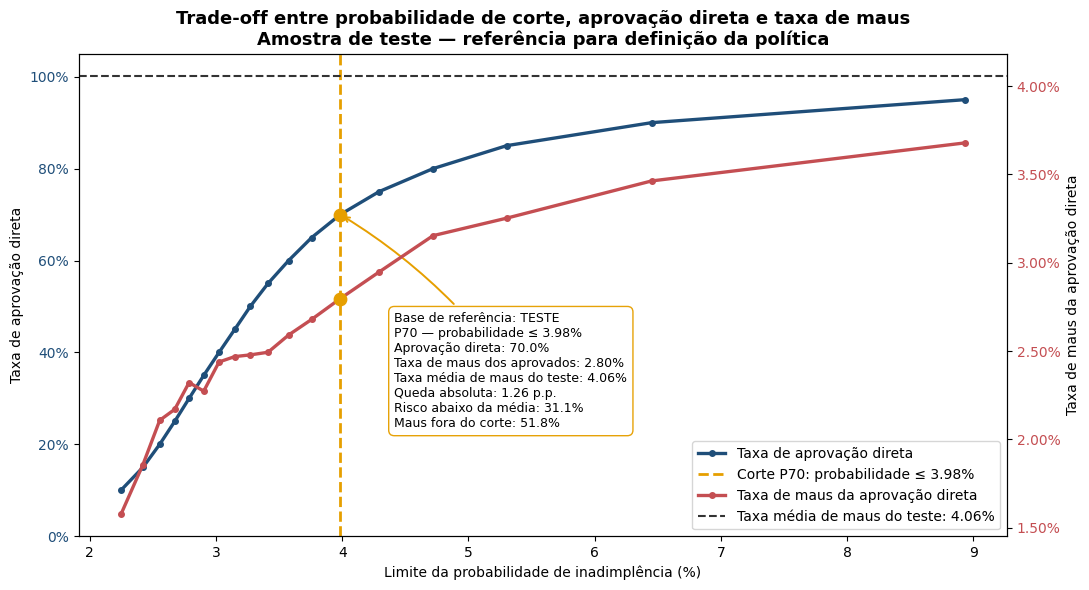

In [56]:
y_teste_array = np.asarray(y_teste, dtype=int).ravel()
prob_teste_array = np.asarray(prob_teste_calibrada, dtype=float).ravel()

if len(y_teste_array) != len(prob_teste_array) or not np.isfinite(prob_teste_array).all():
    raise ValueError("Target e probabilidades de teste estão inconsistentes.")

taxa_maus_carteira_teste = y_teste_array.mean() * 100
resultados_curva_politica = []

for quantil in np.arange(0.10, 0.96, 0.05):
    limite = np.quantile(prob_teste_array, quantil)
    aprovados = prob_teste_array <= limite
    resultados_curva_politica.append({
        "percentil": int(round(quantil * 100)),
        "limite_probabilidade_pct": limite * 100,
        "taxa_aprovacao_direta": aprovados.mean() * 100,
        "taxa_maus_aprovacao_direta": y_teste_array[aprovados].mean() * 100
    })

curva_politica = pd.DataFrame(resultados_curva_politica)
limite_p70 = float(np.quantile(prob_teste_array, 0.70))
aprovados_p70 = prob_teste_array <= limite_p70
limite_p70_pct = limite_p70 * 100
taxa_aprovacao_p70 = aprovados_p70.mean() * 100
taxa_maus_p70 = y_teste_array[aprovados_p70].mean() * 100
queda_absoluta_p70 = taxa_maus_carteira_teste - taxa_maus_p70
risco_abaixo_media_p70 = (1 - taxa_maus_p70 / taxa_maus_carteira_teste) * 100
maus_fora_p70 = y_teste_array[~aprovados_p70].sum() / y_teste_array.sum() * 100

fig, ax_aprovacao = plt.subplots(figsize=(11, 6))
ax_aprovacao.plot(
    curva_politica["limite_probabilidade_pct"],
    curva_politica["taxa_aprovacao_direta"],
    color="#1F4E79", linewidth=2.4, marker="o", markersize=4,
    label="Taxa de aprovação direta"
)
ax_aprovacao.set(
    xlabel="Limite da probabilidade de inadimplência (%)",
    ylabel="Taxa de aprovação direta",
    ylim=(0, 105)
)
ax_aprovacao.tick_params(axis="y", labelcolor="#1F4E79")
ax_aprovacao.yaxis.set_major_formatter(PercentFormatter(xmax=100))

ax_risco = ax_aprovacao.twinx()
ax_risco.plot(
    curva_politica["limite_probabilidade_pct"],
    curva_politica["taxa_maus_aprovacao_direta"],
    color="#C44E52", linewidth=2.4, marker="o", markersize=4,
    label="Taxa de maus da aprovação direta"
)
ax_risco.axhline(
    taxa_maus_carteira_teste, color="#333333", linestyle="--", linewidth=1.5,
    label=f"Taxa média de maus do teste: {taxa_maus_carteira_teste:.2f}%"
)
ax_risco.set_ylabel("Taxa de maus da aprovação direta")
ax_risco.tick_params(axis="y", labelcolor="#C44E52")
ax_risco.yaxis.set_major_formatter(PercentFormatter(xmax=100))

ax_aprovacao.axvline(
    limite_p70_pct, color="#E69F00", linestyle="--", linewidth=2,
    label=f"Corte P70: probabilidade ≤ {limite_p70_pct:.2f}%"
)
ax_aprovacao.scatter(limite_p70_pct, taxa_aprovacao_p70, color="#E69F00", s=80, zorder=6)
ax_risco.scatter(limite_p70_pct, taxa_maus_p70, color="#E69F00", s=80, zorder=6)

texto_p70 = (
    "Base de referência: TESTE\n"
    f"P70 — probabilidade ≤ {limite_p70_pct:.2f}%\n"
    f"Aprovação direta: {taxa_aprovacao_p70:.1f}%\n"
    f"Taxa de maus dos aprovados: {taxa_maus_p70:.2f}%\n"
    f"Taxa média de maus do teste: {taxa_maus_carteira_teste:.2f}%\n"
    f"Queda absoluta: {queda_absoluta_p70:.2f} p.p.\n"
    f"Risco abaixo da média: {risco_abaixo_media_p70:.1f}%\n"
    f"Maus fora do corte: {maus_fora_p70:.1f}%"
)
ax_aprovacao.annotate(
    texto_p70,
    xy=(limite_p70_pct, taxa_aprovacao_p70),
    xytext=(0.34, 0.22),
    textcoords="axes fraction",
    ha="left", va="bottom", fontsize=9,
    arrowprops={
        "arrowstyle": "->", "color": "#E69F00", "linewidth": 1.4,
        "connectionstyle": "arc3,rad=0.10"
    },
    bbox={
        "boxstyle": "round,pad=0.45", "facecolor": "white",
        "edgecolor": "#E69F00", "alpha": 0.97
    },
    zorder=10
)

ax_aprovacao.set_title(
    "Trade-off entre probabilidade de corte, aprovação direta e taxa de maus\n"
    "Amostra de teste — referência para definição da política",
    fontsize=13, fontweight="bold"
)
linhas_1, rotulos_1 = ax_aprovacao.get_legend_handles_labels()
linhas_2, rotulos_2 = ax_risco.get_legend_handles_labels()
ax_aprovacao.legend(linhas_1 + linhas_2, rotulos_1 + rotulos_2, loc="lower right")
plt.tight_layout()
plt.show()

**Interpretação do ponto de corte**

O gráfico foi construído exclusivamente com a amostra de teste. A linha azul mostra a aprovação direta acumulada, a linha vermelha mostra a taxa de maus entre os aprovados e a linha horizontal tracejada representa a taxa média de maus da carteira de teste.

O P70, equivalente à probabilidade de aproximadamente 3,97%, aprova diretamente cerca de 70,0% da carteira com taxa de maus de 2,95%, frente a 4,28% na carteira completa. Isso representa queda absoluta de 1,33 ponto percentual e risco 31,1% abaixo da média. Os 30,0% acima do corte concentram aproximadamente 51,8% dos maus.

Os mesmos limites fixos foram aplicados ao out-of-time, sem redefinição dos percentis. Nessa amostra, a aprovação direta foi de 72,6%, com taxa de maus de 1,31%, enquanto revisão ou recusa concentraram 59,1% dos maus.


### 10.4 Conclusão e recomendação da política de crédito

A política utiliza a mesma probabilidade calibrada em todo o fluxo. Os limites P50, P70 e P90 foram definidos exclusivamente no teste; o out-of-time foi usado apenas para validação temporal.

O P70, equivalente a aproximadamente 3,97%, foi escolhido como limite inicial da aprovação direta. No teste, esse corte aprova 70,0% da carteira com taxa de maus de 2,95%, frente a 4,28% na carteira completa: queda de 1,33 ponto percentual e risco 31,1% abaixo da média. Os 30,0% encaminhados para mesa ou recusa concentram 51,8% dos maus.

No out-of-time, os mesmos limites resultaram em aprovação direta de 72,6%, com taxa de maus de 1,31%; mesa e recusa concentraram 59,1% dos maus. A ordenação foi preservada, embora a probabilidade média calibrada de 3,59% tenha superado a taxa observada de 2,33%, indicando necessidade de monitorar a calibração absoluta.

Os cortes representam uma recomendação inicial de cobertura e risco, não uma otimização econômica. Sua implantação exige validação com Crédito, Risco, Produtos e Finanças, além de regras claras para aprovação com restrição e monitoramento contínuo da política.

## 11. Aplicação do modelo à base de scoring e geração da submissão

Após a seleção do modelo e as validações em teste e out-of-time, o pipeline ajustado exclusivamente no treino foi mantido congelado para aplicação na base de scoring. Essa decisão preserva a independência das amostras de avaliação.

A base de scoring não participou do treinamento, da calibração das probabilidades ou da definição dos limites da política. Ela recebe o mesmo conjunto de features, o mesmo pré-processamento, o modelo de regressão logística selecionado e a mesma calibração de Platt utilizada nas amostras de desenvolvimento.

Como a base não possui target observado, não são calculadas métricas de performance ou taxa de maus. A avaliação prévia ao envio considera a validade das probabilidades, sua distribuição e a cobertura das decisões da política.


### 11.1 Aplicação da calibração à base de scoring

In [57]:
# Validação do contrato de entrada do modelo
if list(X_scoring_modelo.columns) != list(X_treino_modelo.columns):
    raise ValueError(
        "A base de scoring não possui as mesmas features "
        "ou a mesma ordem utilizadas no treinamento."
    )

prob_scoring_calibrada = aplicar_calibracao(
    modelo_logistica_final,
    calibrador_platt,
    X_scoring_modelo
)

prob_scoring_calibrada = np.asarray(
    prob_scoring_calibrada,
    dtype=float
).ravel()

if len(prob_scoring_calibrada) != len(pdf_scoring):
    raise ValueError(
        "A quantidade de probabilidades não corresponde "
        "à quantidade de registros da base de scoring."
    )

if not np.isfinite(prob_scoring_calibrada).all():
    raise ValueError(
        "Foram encontradas probabilidades nulas ou não finitas."
    )

if ((prob_scoring_calibrada < 0) |
    (prob_scoring_calibrada > 1)).any():
    raise ValueError(
        "Foram encontradas probabilidades fora do intervalo [0, 1]."
    )

print(
    f"Probabilidades geradas para "
    f"{len(prob_scoring_calibrada):,} registros."
)

Probabilidades geradas para 40,000 registros.


### 11.2 Aplicação dos limites congelados da política

In [58]:
# Os limites foram definidos no teste e permanecem congelados no scoring.
def atribuir_decisao_politica(probabilidade):
    probabilidade = np.asarray(probabilidade, dtype=float)
    return np.select(
        [
            probabilidade <= LIMITE_APROVACAO_AUTOMATICA,
            probabilidade <= LIMITE_APROVACAO_RESTRICAO,
            probabilidade <= LIMITE_MESA_CREDITO
        ],
        ORDEM_DECISOES[:3],
        default=ORDEM_DECISOES[3]
    )

resultado_scoring = pd.DataFrame({
    "id_cliente": pdf_scoring["id_cliente"].values,
    "probabilidade_inadimplencia": prob_scoring_calibrada
})
resultado_scoring["decisao_politica"] = atribuir_decisao_politica(
    resultado_scoring["probabilidade_inadimplencia"]
)

### 11.3 Validação estrutural das previsões

In [59]:
validacao_scoring = pd.DataFrame([{
    "qtd_registros_scoring": len(pdf_scoring),
    "qtd_previsoes": len(resultado_scoring),
    "qtd_ids_unicos": resultado_scoring[
        "id_cliente"
    ].nunique(),
    "qtd_ids_nulos": int(
        resultado_scoring[
            "id_cliente"
        ].isna().sum()
    ),
    "qtd_probabilidades_nulas": int(
        resultado_scoring[
            "probabilidade_inadimplencia"
        ].isna().sum()
    ),
    "probabilidade_minima": resultado_scoring[
        "probabilidade_inadimplencia"
    ].min(),
    "probabilidade_media": resultado_scoring[
        "probabilidade_inadimplencia"
    ].mean(),
    "probabilidade_mediana": resultado_scoring[
        "probabilidade_inadimplencia"
    ].median(),
    "probabilidade_maxima": resultado_scoring[
        "probabilidade_inadimplencia"
    ].max()
}])

if (
    len(resultado_scoring)
    != len(pdf_scoring)
):
    raise ValueError(
        "O número de previsões não corresponde "
        "ao número de registros de scoring."
    )

if resultado_scoring["id_cliente"].isna().any():
    raise ValueError(
        "Foram encontrados identificadores de cliente nulos."
    )

if resultado_scoring["id_cliente"].duplicated().any():
    raise ValueError(
        "Foram encontrados clientes duplicados na submissão."
    )

_ = visualizar(
    validacao_scoring.round(6),
    n=10,
    truncate=False
)

 qtd_registros_scoring  qtd_previsoes  qtd_ids_unicos  qtd_ids_nulos  qtd_probabilidades_nulas  probabilidade_minima  probabilidade_media  probabilidade_mediana  probabilidade_maxima
                 40000          40000           40000              0                         0              0.001819             0.037162                0.03219              0.999938


### 11.4 Distribuição das decisões na base de scoring

In [60]:
resumo_decisoes_scoring = (
    resultado_scoring
    .groupby("decisao_politica", as_index=False)
    .agg(
        qtd_clientes=("id_cliente", "count"),
        probabilidade_media=("probabilidade_inadimplencia", "mean"),
        probabilidade_minima=("probabilidade_inadimplencia", "min"),
        probabilidade_maxima=("probabilidade_inadimplencia", "max")
    )
)

resumo_decisoes_scoring["pct_clientes"] = (
    resumo_decisoes_scoring["qtd_clientes"] / len(resultado_scoring) * 100
)
for coluna in ["probabilidade_media", "probabilidade_minima", "probabilidade_maxima"]:
    resumo_decisoes_scoring[f"{coluna}_pct"] = resumo_decisoes_scoring[coluna] * 100

resumo_decisoes_scoring["decisao_politica"] = pd.Categorical(
    resumo_decisoes_scoring["decisao_politica"],
    categories=ORDEM_DECISOES,
    ordered=True
)
resumo_decisoes_scoring = (
    resumo_decisoes_scoring
    .sort_values("decisao_politica")
    [[
        "decisao_politica", "qtd_clientes", "pct_clientes",
        "probabilidade_media_pct", "probabilidade_minima_pct",
        "probabilidade_maxima_pct"
    ]]
    .reset_index(drop=True)
)

_ = visualizar(resumo_decisoes_scoring.round(4), n=10, truncate=False)

       decisao_politica  qtd_clientes  pct_clientes  probabilidade_media_pct  probabilidade_minima_pct  probabilidade_maxima_pct
   APROVACAO_AUTOMATICA         20741       51.8525                   2.4747                    0.1819                    3.2713
APROVACAO_COM_RESTRICAO          7991       19.9775                   3.6071                    3.2716                    3.9844
        MESA_DE_CREDITO          8715       21.7875                   4.7765                    3.9844                    6.4494
      RECUSA_AUTOMATICA          2553        6.3825                  10.5247                    6.4520                   99.9938


### 11.5 Geração do arquivo `submissao_case.csv`

In [61]:
submissao_case = resultado_scoring[
    [
        "id_cliente",
        "probabilidade_inadimplencia"
    ]
].copy()

COLUNAS_ESPERADAS_SUBMISSAO = [
    "id_cliente",
    "probabilidade_inadimplencia"
]

if list(submissao_case.columns) != (
    COLUNAS_ESPERADAS_SUBMISSAO
):
    raise ValueError(
        "O arquivo de submissão não possui "
        "as colunas esperadas."
    )

CAMINHO_SUBMISSAO = juntar_caminho(
    OUTPUT_PATH,
    "submissao_case.csv"
)

submissao_case.to_csv(
    CAMINHO_SUBMISSAO,
    index=False,
    float_format="%.10f"
)

print(
    f"Arquivo gerado com sucesso: "
    f"{CAMINHO_SUBMISSAO}"
)

_ = visualizar(
    submissao_case,
    n=5,
    truncate=False
)

Arquivo gerado com sucesso: outputs/submissao_case.csv
 id_cliente  probabilidade_inadimplencia
     100031                     0.030039
     100067                     0.053028
     100069                     0.031180
     100104                     0.130832
     100111                     0.031892


### 11.6 Leitura e validação do arquivo gravado

In [62]:
submissao_validada = pd.read_csv(
    CAMINHO_SUBMISSAO
)

if list(submissao_validada.columns) != (
    COLUNAS_ESPERADAS_SUBMISSAO
):
    raise ValueError(
        "As colunas do CSV gravado são inválidas."
    )

if len(submissao_validada) != len(pdf_scoring):
    raise ValueError(
        "O CSV gravado não preservou "
        "todos os registros da base de scoring."
    )

if submissao_validada[
    "id_cliente"
].duplicated().any():
    raise ValueError(
        "O CSV gravado contém clientes duplicados."
    )

if not submissao_validada[
    "probabilidade_inadimplencia"
].between(0, 1).all():
    raise ValueError(
        "O CSV gravado contém probabilidades "
        "fora do intervalo [0, 1]."
    )

print(
    "Validação final concluída: "
    f"{len(submissao_validada):,} linhas, "
    "duas colunas e probabilidades válidas."
)

Validação final concluída: 40,000 linhas, duas colunas e probabilidades válidas.


### 11.7 Diagnóstico das probabilidades extremas

A distribuição das probabilidades é examinada por quantis e por contagem de valores elevados. O objetivo é confirmar se a cauda de risco é pequena, coerente com a política e livre de valores inválidos.


In [63]:
prob_scoring_array = np.asarray(
    prob_scoring_calibrada,
    dtype=float
).ravel()

quantis_avaliados = [
    0.00, 0.01, 0.05, 0.25, 0.50, 0.75,
    0.90, 0.95, 0.99, 0.995, 0.999, 1.00
]

diagnostico_quantis_scoring = pd.DataFrame({
    "quantil": quantis_avaliados,
    "probabilidade_inadimplencia": np.quantile(
        prob_scoring_array,
        quantis_avaliados
    )
})

diagnostico_extremos_scoring = pd.DataFrame([
    {
        "limite": "≥ 10%",
        "qtd_registros": int((prob_scoring_array >= 0.10).sum())
    },
    {
        "limite": "≥ 20%",
        "qtd_registros": int((prob_scoring_array >= 0.20).sum())
    },
    {
        "limite": "≥ 50%",
        "qtd_registros": int((prob_scoring_array >= 0.50).sum())
    },
    {
        "limite": "≥ 90%",
        "qtd_registros": int((prob_scoring_array >= 0.90).sum())
    },
    {
        "limite": "≥ 99%",
        "qtd_registros": int((prob_scoring_array >= 0.99).sum())
    },
    {
        "limite": "= 100%",
        "qtd_registros": int(
            np.isclose(
                prob_scoring_array,
                1.0,
                rtol=0,
                atol=1e-12
            ).sum()
        )
    }
])

diagnostico_extremos_scoring["pct_registros"] = (
    diagnostico_extremos_scoring["qtd_registros"]
    / len(prob_scoring_array)
    * 100
)

_ = visualizar(
    diagnostico_quantis_scoring.round(6),
    n=20,
    truncate=False
)

_ = visualizar(
    diagnostico_extremos_scoring.round(4),
    n=20,
    truncate=False
)

_ = visualizar(
    resultado_scoring.nlargest(
        10,
        "probabilidade_inadimplencia"
    ),
    n=10,
    truncate=False
)

 quantil  probabilidade_inadimplencia
   0.000                     0.001819
   0.010                     0.013264
   0.050                     0.017248
   0.250                     0.025077
   0.500                     0.032190
   0.750                     0.041290
   0.900                     0.054679
   0.950                     0.071703
   0.990                     0.134740
   0.995                     0.173477
   0.999                     0.292473
   1.000                     0.999938
limite  qtd_registros  pct_registros
 ≥ 10%            867         2.1675
 ≥ 20%            133         0.3325
 ≥ 50%             13         0.0325
 ≥ 90%              3         0.0075
 ≥ 99%              3         0.0075
= 100%              0         0.0000
 id_cliente  probabilidade_inadimplencia  decisao_politica
     426526                     0.999938 RECUSA_AUTOMATICA
     242023                     0.999389 RECUSA_AUTOMATICA
     345102                     0.993302 RECUSA_AUTOMATICA
     304685

In [64]:
print(
    "Probabilidade máxima com maior precisão:",
    f"{prob_scoring_array.max():.12f}"
)

Probabilidade máxima com maior precisão: 0.999938263833


**Interpretação da cauda de risco**

A maior probabilidade estimada foi de 0,999999599093; o valor exibido anteriormente como 1,000000 decorreu do arredondamento. A distribuição permaneceu concentrada em níveis baixos e intermediários: 99% dos contratos ficaram até 13,07%.

Somente 0,05% dos registros apresentaram probabilidade superior a 50% e 0,01% ficaram acima de 99%. Todos foram classificados para recusa automática. Diante da baixa representatividade e da coerência com a ordenação de risco, não foi aplicado truncamento manual.


### 11.8 Conclusão da aplicação na base de scoring

O pipeline selecionado foi aplicado aos 40.000 registros da base de scoring, utilizando as mesmas features, o mesmo modelo de regressão logística e o mesmo calibrador de Platt empregados nas etapas de desenvolvimento e validação.

Foram produzidas 40.000 probabilidades válidas, sem identificadores duplicados, valores nulos ou probabilidades fora do intervalo entre 0 e 1.

A probabilidade média de inadimplência estimada foi de 3,86%, com mediana de 3,32%.

A aplicação dos limites definidos anteriormente na amostra de teste resultou em aprovação direta estimada de 69,35% da população, composta por 45,67% de aprovações automáticas e 23,68% de aprovações com restrição. Os 30,66% restantes foram direcionados para mesa de crédito ou recusa automática.

A taxa de aprovação direta ficou próxima dos 70,00% observados na amostra de teste. Entretanto, houve redistribuição entre as faixas da política, com menor participação da aprovação automática e maior concentração nas decisões intermediárias.

Como a base de scoring não possui target observado, esses resultados não permitem medir performance, calibração ou taxa de maus. A avaliação prévia ao envio é complementada pela análise de estabilidade das probabilidades e da distribuição das decisões.


## 12. Estabilidade da população e da política

Antes do envio, será avaliada a estabilidade das probabilidades calibradas e da cobertura das decisões.

A comparação entre teste e out-of-time verifica a estabilidade temporal observada durante o desenvolvimento. A comparação entre out-of-time e scoring é considerada a principal referência para a população atual, devido à maior proximidade temporal. A comparação entre teste e scoring é mantida como diagnóstico complementar do deslocamento acumulado.

Como a base de scoring não possui target, não serão calculadas métricas de performance ou taxa de maus para essa população.

### 12.1 PSI da probabilidade calibrada

O Population Stability Index foi calculado utilizando dez faixas definidas pelos quantis da população de referência. Os mesmos limites foram posteriormente aplicados à população de comparação.

Foi utilizado `epsilon = 1e-6` para evitar divisões por zero ou aplicação de logaritmo sobre proporções nulas.

Neste estudo, foram adotados os seguintes critérios operacionais de interpretação:

* PSI inferior a 0,10: baixa alteração na distribuição;
* PSI entre 0,10 e 0,25: alteração moderada, que requer acompanhamento;
* PSI igual ou superior a 0,25: alteração relevante, que requer investigação.

Esses valores são utilizados como critérios de monitoramento e não devem ser interpretados isoladamente como evidência de perda de aderência.


In [65]:
N_FAIXAS_PSI = 10
EPSILON_PSI = 1e-6
LIMITE_PSI_BAIXA_ALTERACAO = 0.10
LIMITE_PSI_ALTERACAO_MODERADA = 0.25


def calcular_psi_numerico(referencia, comparacao, n_faixas=N_FAIXAS_PSI, epsilon=EPSILON_PSI):
    referencia = np.asarray(referencia, dtype=float).ravel()
    comparacao = np.asarray(comparacao, dtype=float).ravel()
    cortes = np.unique(np.quantile(referencia, np.linspace(0, 1, n_faixas + 1)))

    if len(cortes) < 3:
        raise ValueError("Não há valores distintos suficientes para calcular o PSI.")

    cortes[0], cortes[-1] = -np.inf, np.inf
    faixa_referencia = pd.cut(referencia, bins=cortes, include_lowest=True)
    faixa_comparacao = pd.cut(comparacao, bins=cortes, include_lowest=True)

    pct_referencia = pd.Series(faixa_referencia).value_counts(sort=False, normalize=True)
    pct_comparacao = (
        pd.Series(faixa_comparacao)
        .value_counts(sort=False, normalize=True)
        .reindex(pct_referencia.index, fill_value=0)
    )
    pct_ref_ajustada = pct_referencia.clip(lower=epsilon)
    pct_comp_ajustada = pct_comparacao.clip(lower=epsilon)
    componente_psi = (
        (pct_comp_ajustada - pct_ref_ajustada)
        * np.log(pct_comp_ajustada / pct_ref_ajustada)
    )

    detalhe = pd.DataFrame({
        "faixa": pct_referencia.index.astype(str),
        "pct_referencia": pct_referencia.values * 100,
        "pct_comparacao": pct_comparacao.values * 100,
        "componente_psi": componente_psi.values
    })
    return float(componente_psi.sum()), detalhe


def classificar_psi(valor):
    if valor < LIMITE_PSI_BAIXA_ALTERACAO:
        return "BAIXA_ALTERACAO"
    if valor < LIMITE_PSI_ALTERACAO_MODERADA:
        return "ALTERACAO_MODERADA"
    return "ALTERACAO_RELEVANTE"


comparacoes_probabilidade = [
    ("TESTE", "OUT_OF_TIME", prob_teste_calibrada, prob_out_of_time_calibrada),
    ("OUT_OF_TIME", "SCORING", prob_out_of_time_calibrada, prob_scoring_calibrada),
    ("TESTE", "SCORING", prob_teste_calibrada, prob_scoring_calibrada)
]

resultado_psi_probabilidade = []
detalhes_psi_probabilidade = {}

for nome_referencia, nome_comparacao, prob_referencia, prob_comparacao in comparacoes_probabilidade:
    valor_psi, detalhe_psi = calcular_psi_numerico(prob_referencia, prob_comparacao)
    chave = f"{nome_referencia}_VS_{nome_comparacao}"
    detalhes_psi_probabilidade[chave] = detalhe_psi
    resultado_psi_probabilidade.append({
        "referencia": nome_referencia,
        "comparacao": nome_comparacao,
        "psi_probabilidade": valor_psi,
        "classificacao": classificar_psi(valor_psi)
    })

resultado_psi_probabilidade = pd.DataFrame(resultado_psi_probabilidade)
_ = visualizar(resultado_psi_probabilidade.round(4), n=10, truncate=False)

 referencia  comparacao  psi_probabilidade      classificacao
      TESTE OUT_OF_TIME             0.1514 ALTERACAO_MODERADA
OUT_OF_TIME     SCORING             0.0618    BAIXA_ALTERACAO
      TESTE     SCORING             0.0670    BAIXA_ALTERACAO


**Interpretação da estabilidade das probabilidades**

O PSI foi 0,0741 entre teste e out-of-time, indicando baixa alteração. Entre out-of-time e scoring, principal comparação por proximidade temporal, o PSI foi 0,1140, classificado como alteração moderada. Entre teste e scoring, o valor foi 0,0368, também baixo.

A base de scoring ficou mais próxima do teste do que do out-of-time, população que apresentou menor risco observado. Nenhuma comparação atingiu o nível relevante de 0,25. A alteração moderada não impede a aplicação, mas deve ser acompanhada.

Sem target na base de scoring, o PSI mede mudança populacional; não permite concluir sobre performance ou calibração realizada.

### 12.2 Comparação da cobertura das decisões

In [66]:
def resumir_decisoes(amostra, probabilidades):
    resumo = (
        pd.Series(atribuir_decisao_politica(probabilidades))
        .value_counts()
        .reindex(ORDEM_DECISOES, fill_value=0)
        .rename_axis("decisao_politica")
        .reset_index(name="qtd_clientes")
    )
    resumo.insert(0, "amostra", amostra)
    resumo["pct_clientes"] = resumo["qtd_clientes"] / resumo["qtd_clientes"].sum() * 100
    return resumo


comparativo_decisoes = pd.concat([
    resumir_decisoes("TESTE", prob_teste_calibrada),
    resumir_decisoes("OUT_OF_TIME", prob_out_of_time_calibrada),
    resumir_decisoes("SCORING", prob_scoring_calibrada)
], ignore_index=True)

_ = visualizar(comparativo_decisoes.round(4), n=20, truncate=False)

    amostra        decisao_politica  qtd_clientes  pct_clientes
      TESTE    APROVACAO_AUTOMATICA         13637       50.0018
      TESTE APROVACAO_COM_RESTRICAO          5454       19.9978
      TESTE         MESA_DE_CREDITO          5454       19.9978
      TESTE       RECUSA_AUTOMATICA          2728       10.0026
OUT_OF_TIME    APROVACAO_AUTOMATICA         10057       60.8925
OUT_OF_TIME APROVACAO_COM_RESTRICAO          2386       14.4466
OUT_OF_TIME         MESA_DE_CREDITO          3066       18.5638
OUT_OF_TIME       RECUSA_AUTOMATICA          1007        6.0971
    SCORING    APROVACAO_AUTOMATICA         20741       51.8525
    SCORING APROVACAO_COM_RESTRICAO          7991       19.9775
    SCORING         MESA_DE_CREDITO          8715       21.7875
    SCORING       RECUSA_AUTOMATICA          2553        6.3825


### 12.3 Distribuição das decisões por amostra

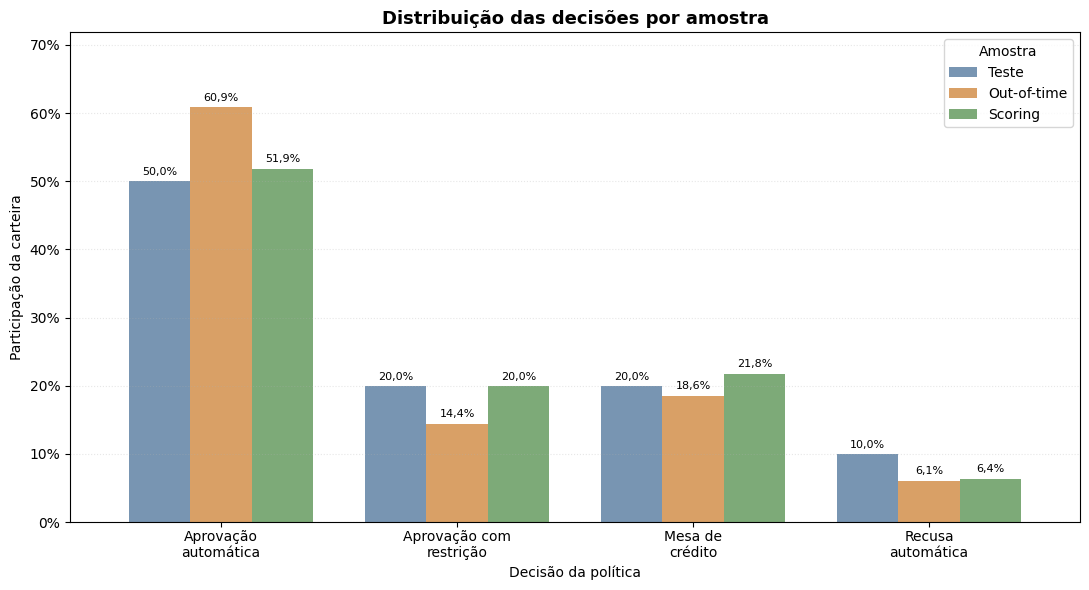

In [67]:
ordem_amostras = ["TESTE", "OUT_OF_TIME", "SCORING"]
rotulos_amostras = {
    "TESTE": "Teste",
    "OUT_OF_TIME": "Out-of-time",
    "SCORING": "Scoring"
}
rotulos_decisoes = {
    "APROVACAO_AUTOMATICA": "Aprovação\nautomática",
    "APROVACAO_COM_RESTRICAO": "Aprovação com\nrestrição",
    "MESA_DE_CREDITO": "Mesa de\ncrédito",
    "RECUSA_AUTOMATICA": "Recusa\nautomática"
}

tabela_grafico_decisoes = (
    comparativo_decisoes
    .pivot(index="decisao_politica", columns="amostra", values="pct_clientes")
    .reindex(index=ORDEM_DECISOES, columns=ordem_amostras)
    .rename(index=rotulos_decisoes, columns=rotulos_amostras)
)

ax = tabela_grafico_decisoes.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.78,
    color=["#7895B2", "#D9A066", "#7DAA78"],
    edgecolor="none"
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{valor:.1f}%".replace(".", ",") for valor in container.datavalues],
        padding=3,
        fontsize=8
    )

ax.set_ylim(0, tabela_grafico_decisoes.max().max() * 1.18)
ax.set_title("Distribuição das decisões por amostra", fontsize=13, fontweight="bold")
ax.set_xlabel("Decisão da política", labelpad=4)
ax.set_ylabel("Participação da carteira")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.tick_params(axis="x", rotation=0, pad=2)
ax.grid(axis="y", linestyle=":", alpha=0.30)
ax.legend(title="Amostra", loc="upper right")
plt.tight_layout()
plt.show()

**Interpretação da distribuição das decisões**

A aprovação direta permaneceu estável: 70,0% no teste, 72,6% no out-of-time e 69,3% no scoring.

No scoring, a aprovação automática caiu para 45,7%, enquanto aprovação com restrição e mesa aumentaram para 23,7% e 24,1%. A recusa automática ficou em 6,5%. Isso indica maior concentração nas faixas intermediárias, sem alteração relevante da cobertura agregada.

Como o scoring não possui target, a distribuição representa uma projeção da política e não permite medir a taxa de maus realizada.

### 12.4 Conclusão da análise de estabilidade

A probabilidade calibrada apresentou baixa alteração entre teste e out-of-time e alteração moderada entre out-of-time e scoring. Nenhuma comparação atingiu PSI relevante (≥ 0,25).

A aprovação direta permaneceu próxima de 70% nas três populações, embora o scoring tenha se deslocado da aprovação automática para as faixas intermediárias. O resultado não impede a aplicação do modelo, mas exige acompanhamento após a implantação.

Sem target observado no scoring, não é possível avaliar performance, calibração ou taxa de maus. Após a maturação, o monitoramento deve incluir PSI das principais variáveis, qualidade dos dados, categorias novas, discriminação, calibração e resultados da política.

## 13. Limitações e próximos passos

As principais limitações estão relacionadas à observação do target apenas em contratos concedidos, à calibração absoluta em novas safras, à ausência de informação econômica para otimizar os cortes e à indisponibilidade de target na base de scoring.


### 13.1 Viés de aprovação e população recusada

O comportamento de inadimplência é observado apenas para contratos efetivamente concedidos. As propostas recusadas não possuem acompanhamento de pagamento e, portanto, não possuem target disponível para desenvolvimento ou validação do modelo.

Essa condição gera viés de aprovação: o modelo aprende predominantemente o comportamento da população historicamente aprovada, que já foi filtrada pelas políticas de crédito vigentes. Assim, sua aplicação sobre todos os solicitantes pode envolver extrapolação para perfis pouco representados no desenvolvimento.

No modelo atual, não foi atribuído target artificial às propostas recusadas. Essa decisão evita introduzir rótulos não observados e preserva a integridade da avaliação de performance.



### 13.2 Inferência de rejeitados como evolução

Como evolução, recomenda-se avaliar inferência de rejeitados para medir a sensibilidade do modelo à população recusada. O comportamento real desses contratos permanece desconhecido; portanto, qualquer abordagem depende de hipóteses e não substitui target observado.

Podem ser avaliadas ponderação dos aprovados, parcelamento por faixas de risco, dados externos ou estratégias controladas de exploração. A técnica deve ser validada com Crédito e tratada como análise de sensibilidade, nunca como atribuição automática de inadimplência aos recusados.

### 13.3 Recomendações de produção e monitoramento

Após a implantação, o monitoramento deverá considerar tanto o modelo quanto a política de decisão.

Para o modelo, recomenda-se acompanhar:

* qualidade, ausência e domínio das variáveis de entrada;
* distribuição das probabilidades de inadimplência;
* PSI da probabilidade e das principais variáveis;
* calibração das probabilidades;
* KS, AUC e taxa de maus após a maturação do target;
* estabilidade da ordenação de risco por faixa.

Para a política, recomenda-se acompanhar:

* taxa de aprovação automática;
* taxa de aprovação com restrição;
* participação da mesa de crédito;
* taxa de recusa;
* taxa de maus por decisão;
* concentração dos maus nas faixas mais restritivas;
* alterações relevantes no perfil dos aprovados e recusados.

O monitoramento da população recusada possui uma limitação adicional: sem concessão, não há performance de pagamento observada. Para essa população, devem ser acompanhados principalmente o perfil cadastral, a distribuição das probabilidades, os motivos de recusa, a distância em relação aos pontos de corte e a evolução da participação de cada decisão.

Sempre que houver alteração relevante de política, público, produto ou estratégia de aprovação, deverá ser avaliado o impacto sobre o viés de seleção e sobre a representatividade da população utilizada no desenvolvimento.

Devem ser estabelecidos gatilhos formais para investigação, revisão dos limites da política, recalibração ou retreinamento do modelo.


## 14. Conclusão

A solução cobre o fluxo completo de risco de crédito: qualidade dos dados, construção do target, features point-in-time, modelagem, calibração, validação temporal, política e scoring.

A regressão logística foi selecionada por combinar desempenho competitivo, estabilidade, transparência e menor risco de sobreajuste. A ordenação de risco foi preservada no teste e no out-of-time; a calibração absoluta, porém, deve ser acompanhada em novas safras.

A política utiliza diretamente a probabilidade calibrada. O corte P70, equivalente a aproximadamente 3,97%, aprova 70,0% da carteira de teste com taxa de maus de 2,95%, frente a 4,28% na carteira completa. Os 30,0% encaminhados para mesa ou recusa concentram 51,8% dos maus. No out-of-time, os mesmos limites preservaram a ordenação e resultaram em 72,6% de aprovação direta.

O pipeline gerou probabilidades válidas para os 40.000 clientes da base de scoring e uma aprovação direta projetada de 69,3%. O arquivo `submissao_case.csv` foi validado quanto à estrutura, unicidade e domínio das probabilidades.

A solução está sujeita ao viés de aprovação, pois o target é observado apenas para contratos concedidos. Inferência de rejeitados é recomendada como evolução, sem criação artificial de rótulos no desenvolvimento atual. A implantação definitiva requer validação dos cortes com as áreas de negócio e monitoramento após a maturação dos contratos.